In [9]:
from pathlib import Path
import os

PROJECT_DIR = Path(r"C:\Users\marco\OneDrive\Desktop\Proyecto")
os.chdir(PROJECT_DIR)

print("Directorio de trabajo:", Path.cwd())

Directorio de trabajo: C:\Users\marco\OneDrive\Desktop\Proyecto


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
nba_master_final = pd.read_csv(r"Datasets\nba_master_final.csv")

In [12]:
team_stats_per_game = pd.read_csv(r"Datasets\Team Stats - Kaggle\Team Stats Per Game.csv")

In [13]:
nba_master_featured = pd.read_csv(r"Datasets\Team Stats - Kaggle\nba_master_featured.csv")

In [14]:
nba_master_team_v2 = pd.read_csv(r"Datasets\Team Stats - Kaggle\nba_master_team_v2.csv")

In [15]:
def setup_plot(title, xlabel, ylabel):

    plt.title(
        title,
        fontsize=16,
        weight="bold",
        pad=15
    )

    plt.xlabel(
        xlabel,
        fontsize=12
    )

    plt.ylabel(
        ylabel,
        fontsize=12
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.30
    )

    plt.tight_layout()

## 1. MAPA DEL CAMBIO

### ¿Cómo ha cambiado la selección de tiro de los jugadores de la NBA?

¿Dónde se lanzan los tiros? (selección de tiro)

In [16]:
print(nba_master_final.columns.tolist())

['Rk', 'Player', 'Age', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Season', 'Rk_adv', 'Team_adv', 'Pos_adv', 'G_adv', 'GS_adv', 'MP_adv', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'Rk_tot', 'Team_tot', 'Pos_tot', 'G_tot', 'GS_tot', 'MP_tot', 'FG_tot', 'FGA_tot', 'FG%_tot', '3P_tot', '3PA_tot', '3P%_tot', '2P_tot', '2PA_tot', '2P%_tot', 'eFG%_tot', 'FT_tot', 'FTA_tot', 'FT%_tot', 'ORB_tot', 'DRB_tot', 'TRB_tot', 'AST_tot', 'STL_tot', 'BLK_tot', 'TOV_tot', 'PF_tot', 'PTS_tot', 'Trp-Dbl', 'Unnamed: 0_level_0_Rk', 'Team_shoot', 'Pos_shoot', 'G_shoot', 'GS_shoot', 'MP_shoot', 'FGPct', 'AvgShotDistance', '% of FGA by Distance_2P', '% of FGA by Distance_0-3', '% of FGA by Distance_3-10', '% of FGA by Distance_10-16', '% of FGA by Distance_16-3P', '% of F

In [17]:
def weighted_mean(values, weights):

    return (
        (values * weights).sum()
        / weights.sum()
    )

In [18]:
shot_profile = (
    nba_master_final
    .groupby("SeasonYear")
    .apply(
        lambda x: pd.Series({

            "Near Rim": weighted_mean(
                x["% of FGA by Distance_0-3"],
                x["FGA"]
            ),

            "Short Mid": weighted_mean(
                x["% of FGA by Distance_3-10"]
                + x["% of FGA by Distance_10-16"],
                x["FGA"]
            ),

            "Long Mid": weighted_mean(
                x["% of FGA by Distance_16-3P"],
                x["FGA"]
            ),

            "Three-Point": weighted_mean(
                x["% of FGA by Distance_3P"],
                x["FGA"]
            )

        })
    )
)

C:\Users\marco\AppData\Local\Temp\ipykernel_77368\864765106.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [19]:
shot_profile["Total"] = (
    shot_profile["Near Rim"]
    + shot_profile["Short Mid"]
    + shot_profile["Long Mid"]
    + shot_profile["Three-Point"]
)

shot_profile

,Near Rim,Short Mid,Long Mid,Three-Point,Total
SeasonYear,,,,,
2000,0.271882,0.326074,0.235050,0.166954,0.999959
2001,0.287432,0.299146,0.235709,0.177718,1.000005
2002,0.290781,0.295279,0.236239,0.177653,0.999953
2003,0.294376,0.287485,0.235299,0.182853,1.000013
2004,0.304908,0.263303,0.237822,0.193948,0.999981
2005,0.310333,0.253555,0.237902,0.198286,1.000076
2006,0.316100,0.242283,0.230743,0.210918,1.000045
2007,0.309351,0.236227,0.233245,0.221173,0.999995
2008,0.317200,0.235900,0.225975,0.220910,0.999986


In [20]:
cross = shot_profile[
    shot_profile["Three-Point"] >
    (shot_profile["Short Mid"] + shot_profile["Long Mid"])
].index.min()

print(cross)

2018


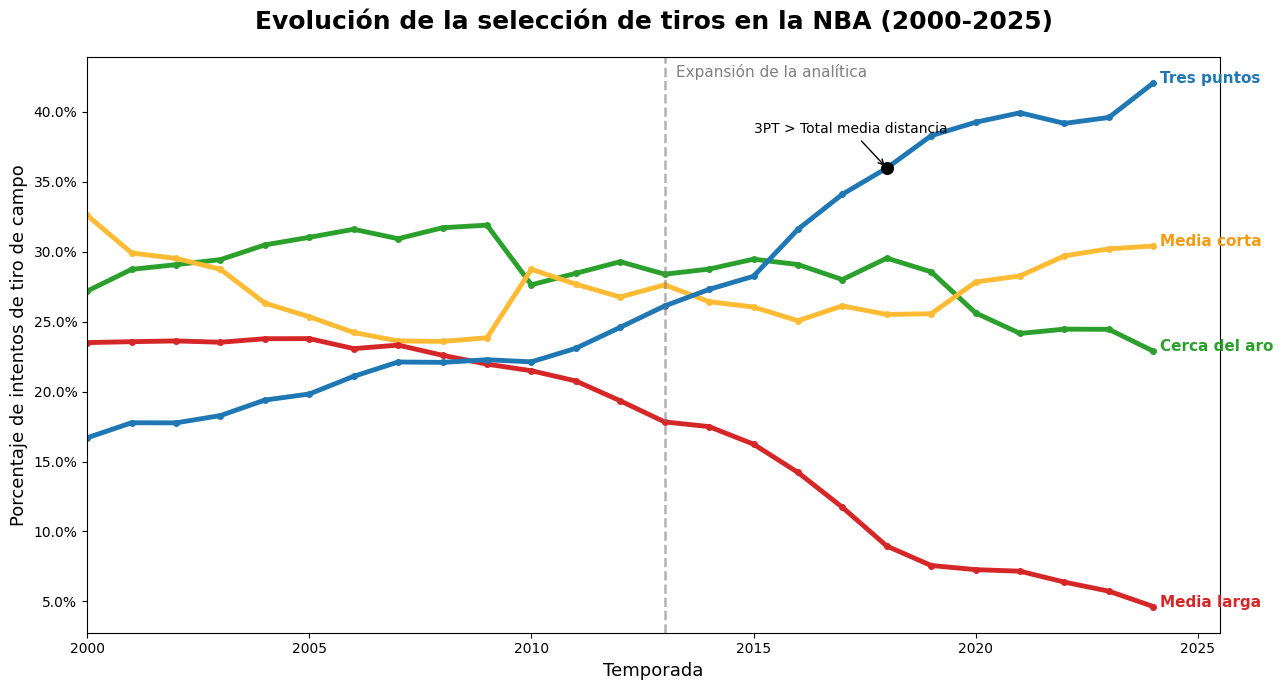

In [21]:
plt.figure(figsize=(13,7))

plt.plot(
    shot_profile.index,
    shot_profile["Near Rim"],
    color="#2ca02c",
    linewidth=3.5,
    marker="o",
    markersize=4
)

plt.plot(
    shot_profile.index,
    shot_profile["Short Mid"],
    color="#ffbb33",
    linewidth=3.5,
    marker="o",
    markersize=4
)

plt.plot(
    shot_profile.index,
    shot_profile["Long Mid"],
    color="#d62728",
    linewidth=3.5,
    marker="o",
    markersize=4
)

plt.plot(
    shot_profile.index,
    shot_profile["Three-Point"],
    color="#1f77b4",
    linewidth=3.5,
    marker="o",
    markersize=4
)

plt.axvline(
    2013,
    color="gray",
    linestyle="--",
    linewidth=1.8,
    alpha=0.6
)

plt.text(
    2013.25,
    0.425,
    "Expansión de la analítica",
    fontsize=11,
    color="gray"
)

last_year = shot_profile.index.max()

plt.text(
    last_year + 0.15,
    shot_profile["Near Rim"].iloc[-1],
    "Cerca del aro",
    color="#2ca02c",
    fontsize=11,
    weight="bold"
)

plt.text(
    last_year + 0.15,
    shot_profile["Short Mid"].iloc[-1],
    "Media corta",
    color="#f39c12",
    fontsize=11,
    weight="bold"
)

plt.text(
    last_year + 0.15,
    shot_profile["Long Mid"].iloc[-1],
    "Media larga",
    color="#d62728",
    fontsize=11,
    weight="bold"
)

plt.text(
    last_year + 0.15,
    shot_profile["Three-Point"].iloc[-1],
    "Tres puntos",
    color="#1f77b4",
    fontsize=11,
    weight="bold"
)

plt.title(
    "Evolución de la selección de tiros en la NBA (2000-2025)",
    fontsize=18,
    weight="bold",
    pad=20
)

plt.xlabel(
    "Temporada",
    fontsize=13
)

plt.ylabel(
    "Porcentaje de intentos de tiro de campo",
    fontsize=13
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

plt.grid(False)

plt.scatter(
    cross,
    shot_profile.loc[cross, "Three-Point"],
    s=70,
    color="black",
    zorder=5
)

plt.annotate(
    "3PT > Total media distancia",
    xy=(cross, shot_profile.loc[cross, "Three-Point"]),
    xytext=(cross - 3, shot_profile.loc[cross, "Three-Point"] + 0.025),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlim(2000, 2025.5)

from matplotlib.ticker import PercentFormatter

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.tight_layout()

plt.show()

La Figura 4.1 muestra la transformación progresiva de la selección de tiro en la NBA durante las últimas dos décadas. Mientras que los lanzamientos de larga media distancia reducen su peso de forma continuada hasta representar menos del 5 % de los intentos, el tiro de tres puntos experimenta un crecimiento sostenido hasta convertirse en la opción ofensiva predominante. mientras que los tiros cercanos al aro mantuvieron una participación relativamente estable. Esta evolución coincide temporalmente con la consolidación de la analítica avanzada en la toma de decisiones deportivas y refleja el cambio estratégico hacia lanzamientos de mayor eficiencia esperada. 

## 2. ¿Qué tipo de tiro ha sustituido al otro? (volumen de 2PA vs 3PA)

In [22]:
team_shot_volume = (

    nba_master_final

    .drop_duplicates(
        subset=["Season", "Team"]
    )

    .groupby("SeasonYear")

    .agg({

        "team_3pa_pg": "mean",

        "team_fga_pg": "mean"

    })

)

team_shot_volume["team_2pa_pg"] = (

    team_shot_volume["team_fga_pg"]

    -

    team_shot_volume["team_3pa_pg"]

)

team_shot_volume.head()

,team_3pa_pg,team_fga_pg,team_2pa_pg
SeasonYear,,,
2000,13.706897,80.603448,66.896552
2001,14.755172,81.268966,66.513793
2002,14.675862,80.782759,66.106897
2003,14.920690,79.817241,64.896552
2004,15.750000,80.336667,64.586667


In [23]:
# Calcular incremento de triples

increase3p = (

    (
        team_shot_volume["team_3pa_pg"].iloc[-1]

        -

        team_shot_volume["team_3pa_pg"].iloc[0]

    )

    /

    team_shot_volume["team_3pa_pg"].iloc[0]

) * 100

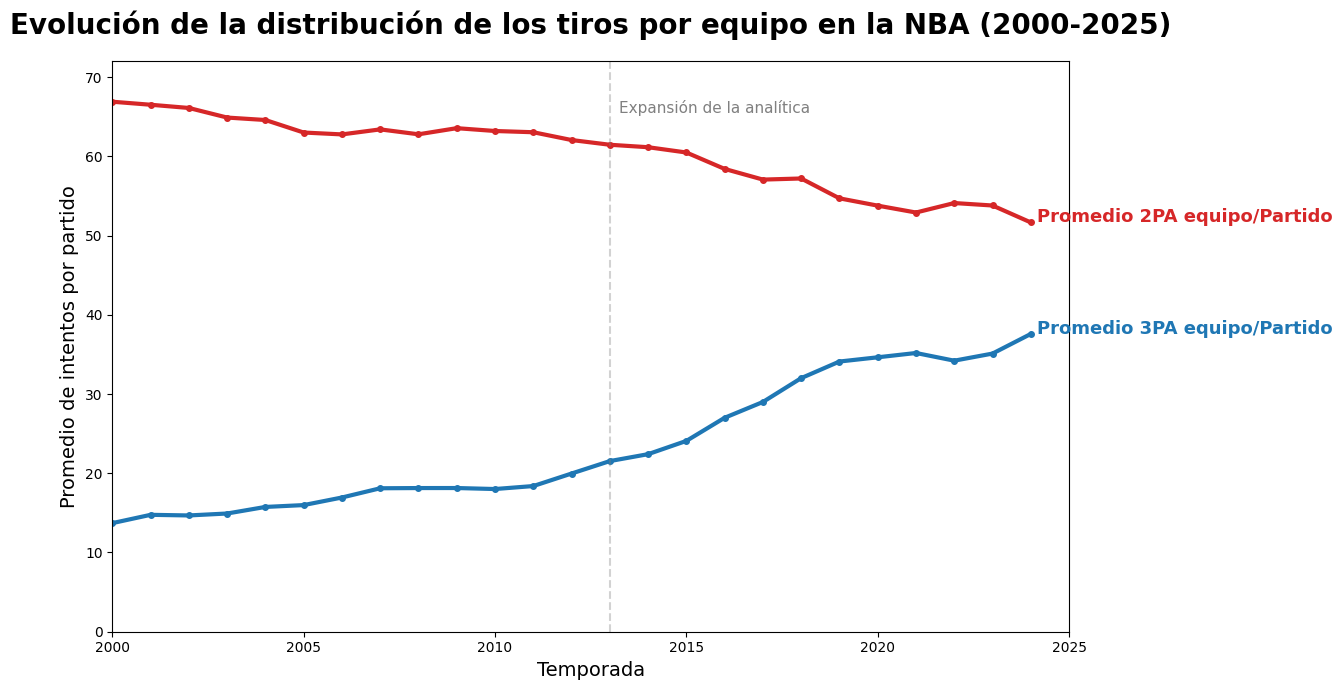

In [24]:
plt.figure(figsize=(13,7))

# Línea de 2PA
plt.plot(

    team_shot_volume.index,

    team_shot_volume["team_2pa_pg"],

    color="#d62728",

    linewidth=3,

    marker="o",

    markersize=4

)

# Línea de 3PA
plt.plot(

    team_shot_volume.index,

    team_shot_volume["team_3pa_pg"],

    color="#1f77b4",

    linewidth=3,

    marker="o",

    markersize=4

)

# Línea vertical
plt.axvline(

    2013,

    color="gray",

    linestyle="--",

    linewidth=1.5,

    alpha=0.35

)

# Texto
plt.text(

    2013.25,

    65.5,

    "Expansión de la analítica",

    fontsize=11,

    color="gray"

)

# Etiquetas finales (sin leyenda)
last = team_shot_volume.index.max()

plt.text(

    last+0.15,

    team_shot_volume["team_3pa_pg"].iloc[-1],

    "Promedio 3PA equipo/Partido",

    fontsize=13,

    weight="bold",

    color="#1f77b4"

)

plt.text(

    last+0.15,

    team_shot_volume["team_2pa_pg"].iloc[-1],

    "Promedio 2PA equipo/Partido",

    fontsize=13,

    weight="bold",

    color="#d62728"

)

# Formato
plt.title(

    "Evolución de la distribución de los tiros por equipo en la NBA (2000-2025)",

    fontsize=20,

    weight="bold",

    pad=20

)

plt.xlabel(

    "Temporada",

    fontsize=14

)

plt.ylabel(

    "Promedio de intentos por partido",

    fontsize=14

)

plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.30

)

plt.grid(False)

plt.ylim(0,72)

plt.xlim(2000,2025)

plt.tight_layout()

plt.show()

La Figura 4.2 muestra cómo el incremento del volumen de lanzamientos de tres puntos no se produjo por un aumento del número total de tiros, sino por una sustitución progresiva de los lanzamientos de dos puntos. Entre las temporadas 2000-01 y 2024-25, el promedio de intentos de tres puntos por partido aumentó aproximadamente un 174 %, mientras que los intentos de dos puntos descendieron de forma continuada. Este cambio refleja la adopción generalizada de estrategias ofensivas basadas en la eficiencia esperada del lanzamiento.

## 4.3 — Evolución de la distancia media de los tiros de campo (2000-2025)

### ¿Cómo aumenta la distancia media de lanzamiento?

In [25]:
shot_distance = (

    nba_master_final

    .groupby("SeasonYear")["AvgShotDistance"]

    .mean()

    .reset_index()

)

In [26]:
increase_dist = (
    (
        shot_distance["AvgShotDistance"].iloc[-1]
        -
        shot_distance["AvgShotDistance"].iloc[0]
    )
    /
    shot_distance["AvgShotDistance"].iloc[0]
) * 100

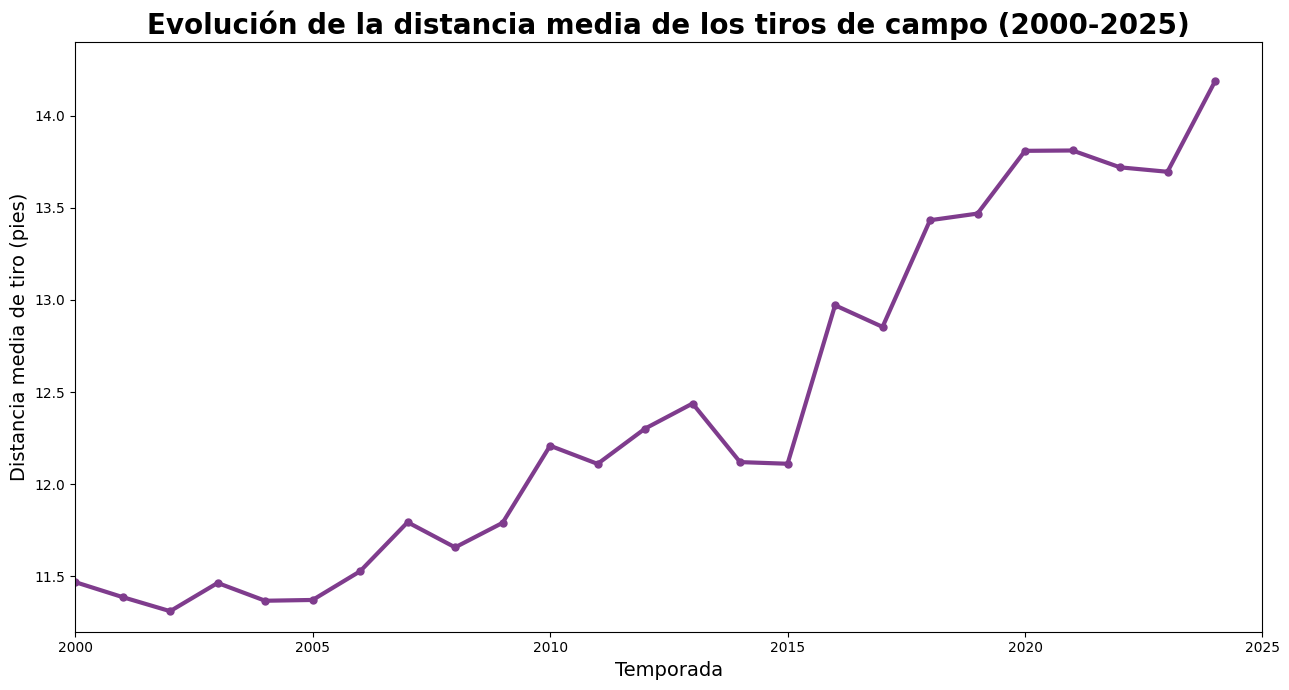

In [27]:
plt.figure(figsize=(13,7))

plt.plot(

    shot_distance["SeasonYear"],

    shot_distance["AvgShotDistance"],

    color="#7f3c8d",

    linewidth=3,

    marker="o",

    markersize=5

)


plt.title(
    "Evolución de la distancia media de los tiros de campo (2000-2025)",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Temporada", fontsize=14)

plt.ylabel("Distancia media de tiro (pies)", fontsize=14)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

plt.grid(False)

plt.ylim(11.2,14.4)

plt.xlim(2000,2025)

plt.tight_layout()


- La distancia media de lanzamiento aumenta de forma continua.
- Hay un cambio de pendiente muy claro alrededor de 2015-2016: 2000-2015: aumento gradual de la distancia media (≈11.3 → 12.1 pies), 2016-2024: incremento mucho más pronunciado (≈12.1 → 14.2 pies). Ese "escalón" coincide exactamente con el auge definitivo del triple. 
- En 2024 se alcanza el máximo histórico.

## 4.4 — Heatmaps por década

In [28]:
# Agrupar por década
shot_heatmap = (

    nba_master_final

    .groupby("Decade")

.apply(
        lambda x: pd.Series({

            "Near Rim": weighted_mean(
                x["% of FGA by Distance_0-3"],
                x["FGA"]
            ),

            "Short Mid": weighted_mean(
                x["% of FGA by Distance_3-10"]
                + x["% of FGA by Distance_10-16"],
                x["FGA"]
            ),

            "Long Mid": weighted_mean(
                x["% of FGA by Distance_16-3P"],
                x["FGA"]
            ),

            "Three-Point": weighted_mean(
                x["% of FGA by Distance_3P"],
                x["FGA"]
            )

        })
    )
)

C:\Users\marco\AppData\Local\Temp\ipykernel_77368\4020805292.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [29]:
# Ordenar décadas
shot_heatmap = shot_heatmap.loc[
    ["2000s", "2010s", "2020s"]
]

In [30]:
# Renombrar columnas
shot_heatmap.columns = [

    "Cerca del aro",

    "Media corta",

    "Media larga",

    "Tres puntos"

]

In [31]:
# Pasar a porcentaje
shot_heatmap = shot_heatmap * 100

In [32]:
labels = shot_heatmap.map(lambda x: f"{x:.1f}%")

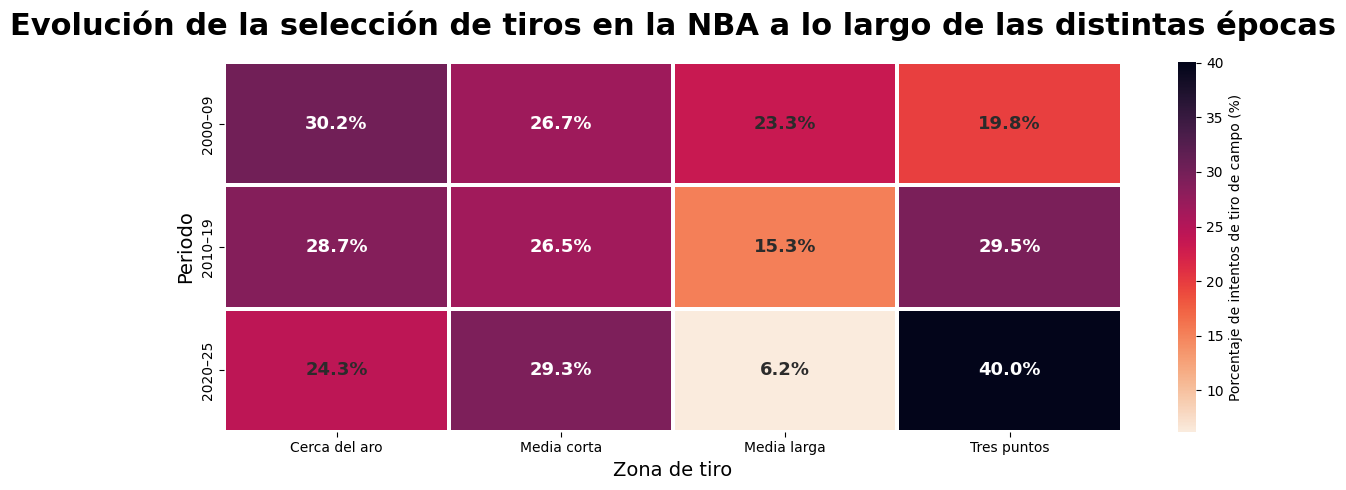

In [33]:
plt.close("all")

import seaborn as sns

shot_heatmap.index = [
    "2000–09",
    "2010–19",
    "2020–25"
]

fig, ax = plt.subplots(figsize=(12,5))

sns.heatmap(
    shot_heatmap,
    annot=labels,
    fmt="",
    cmap="rocket_r",
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"label": "Porcentaje de intentos de tiro de campo (%)"},
    ax=ax
)

plt.title(
    "Evolución de la selección de tiros en la NBA a lo largo de las distintas épocas",
    fontsize=22,
    weight="bold",
    pad=20
)

plt.xlabel(
    "Zona de tiro",
    fontsize=14
)

plt.ylabel(
    "Periodo",
    fontsize=14
)

for text in ax.texts:

    value = float(
        text.get_text().replace("%","")
    )

    if value >= 25:
        text.set_color("white")
    else:
        text.set_color("#2b2b2b")

    text.set_fontsize(13)
    text.set_weight("bold") 

plt.tight_layout()

plt.show()

- La zona cercana al aro pierde peso (33.0% → 26.5%), aunque sigue siendo muy importante.  

- El short mid (3–10 ft) aumenta ligeramente.  

- El mid-range (10–16 ft) cae de forma considerable.  

- El long mid (16 ft–línea de 3) prácticamente desaparece (22.4% → 5.2%).  

- El triple pasa de ser una zona secundaria (18.2%) a convertirse en la principal (40.6%). 

La figura 4.4 ilustra la transformación de la selección de tiros a lo largo de las distintas épocas de la NBA. Si bien los tiros cerca del aro siguieron siendo una fuente importante de ataque, el cambio más notable fue el desplome de los intentos de tiro de media distancia (del 22,4 % al 5,2 % del total de intentos de tiro de campo). Durante el mismo periodo, los intentos de triple aumentaron del 18,2 % al 40,6 %, convirtiéndose en el tipo de tiro más habitual en la NBA moderna. Estos resultados respaldan la hipótesis de que la revolución analítica reasignó principalmente los tiros de media distancia de baja eficacia hacia intentos de triple de mayor valor, en lugar de limitarse a aumentar los tiros desde el perímetro.

## 4.5. Evolución del porcentaje de intentos de tres puntos por posición (2000–2025)

In [34]:
sorted(nba_master_final["Pos"].unique())

['C', 'PF', 'PG', 'SF', 'SG']

In [35]:
position_3par = (
    nba_master_final
    .groupby(["SeasonYear", "Pos"])["3PAr"]
    .mean()
    .reset_index()
)

position_3par = position_3par.pivot(
    index="SeasonYear",
    columns="Pos",
    values="3PAr"
)

In [36]:
growth = (
    (position_3par.loc[2024] - position_3par.loc[2000])
    / position_3par.loc[2000]
    * 100
).round(1)

print(growth.sort_values(ascending=False))

Pos
C     1578.4
PF     425.5
SF     159.8
SG      95.0
PG      85.9
dtype: float64


In [37]:
colors = {
    "PG": "#4C78A8",   # Azul
    "SG": "#72B7B2",   # Turquesa
    "SF": "#54A24B",   # Verde
    "PF": "#ECA82C",   # Naranja
    "C":  "#D62728"    # Rojo
}

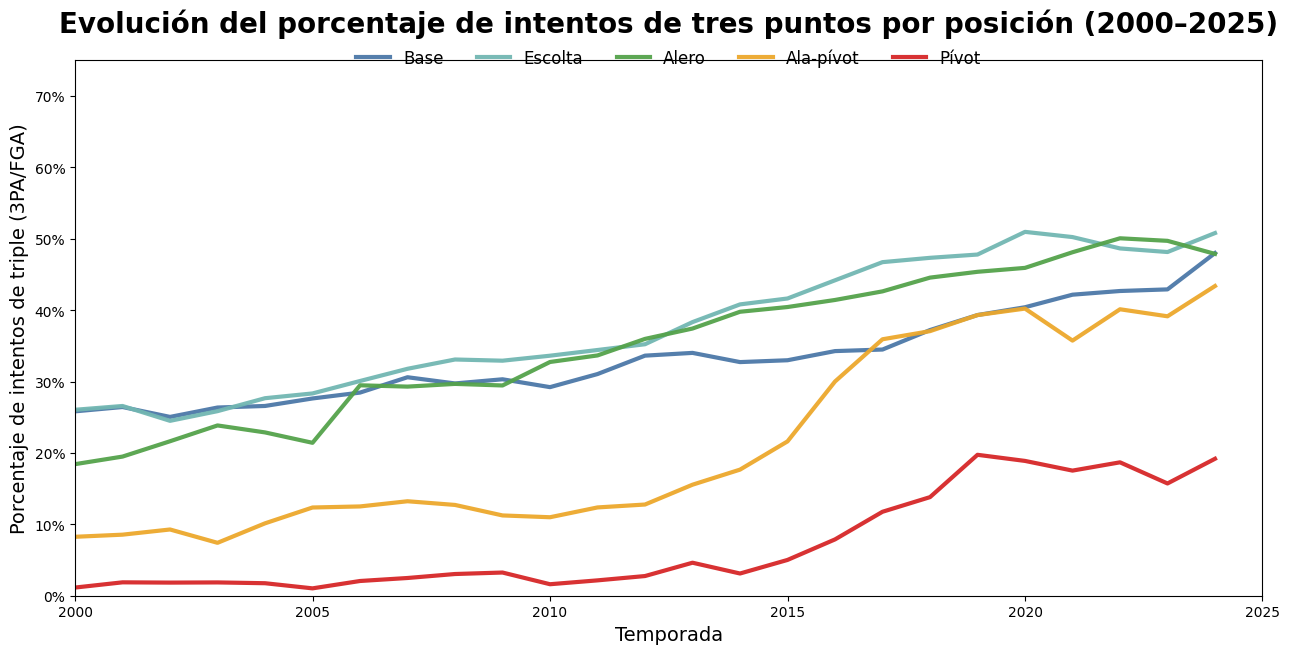

In [38]:
plt.figure(figsize=(13,7))

for pos in ["PG", "SG", "SF", "PF", "C"]:

    plt.plot(
        position_3par.index,
        position_3par[pos],
        color=colors[pos],
        linewidth=3,
        alpha=0.95
    )

# Formato
plt.title(
    "Evolución del porcentaje de intentos de tres puntos por posición (2000–2025)",
    fontsize=20,
    weight="bold",
    pad=20
)

from matplotlib.ticker import PercentFormatter

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.xlabel("Temporada", fontsize=14)

plt.ylabel(
    "Porcentaje de intentos de triple (3PA/FGA)",
    fontsize=14
)

plt.xlim(2000,2025)

plt.ylim(0,0.75)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

plt.grid(False)

plt.legend(
    ["Base", "Escolta", "Alero", "Ala-pívot", "Pívot"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=5,
    frameon=False,
    fontsize=12
)



plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()

Figura 4.5 muestra la evolución del Three-Point Attempt Rate (3PAr) según la posición del jugador entre las temporadas 2000 y 2024. Se observa un incremento sostenido del lanzamiento exterior en las cinco posiciones, especialmente a partir de mediados de la década de 2010, coincidiendo con la consolidación del enfoque analítico en la NBA. Mientras que bases, escoltas y aleros ya presentaban una elevada utilización del triple a comienzos del periodo analizado, los mayores cambios relativos corresponden a los jugadores interiores. En particular, los ala-pívots multiplican aproximadamente por cinco su tasa de intentos desde el perímetro, mientras que los pívots pasan de un uso prácticamente testimonial del triple a incorporarlo de forma habitual dentro de su repertorio ofensivo. Estos resultados evidencian una progresiva homogeneización de las responsabilidades ofensivas entre posiciones y reflejan la transición hacia un baloncesto caracterizado por el espaciado, la versatilidad y la eficiencia en la selección de tiro.

## 4.6. Evolución de los intentos de triples entre los pívots de la NBA

C:\Users\marco\AppData\Local\Temp\ipykernel_77368\2177771436.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


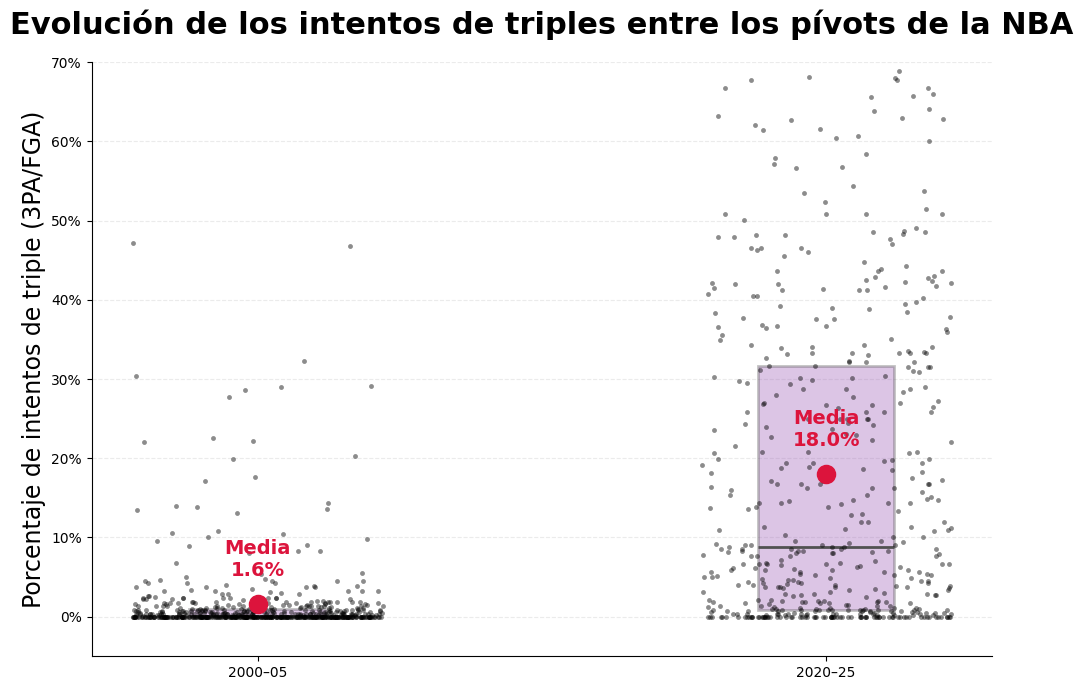

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# Centers: Early 2000s vs Modern NBA
# ======================================================

centers = nba_master_final.loc[nba_master_final["Pos"] == "C"].copy()

centers["Era"] = pd.NA

centers.loc[
    centers["SeasonYear"].between(2000, 2005),
    "Era"
] = "2000–05"

centers.loc[
    centers["SeasonYear"].between(2020, 2025),
    "Era"
] = "2020–25"

centers = centers.dropna(subset=["Era"])

centers["Era"] = pd.Categorical(
    centers["Era"],
    categories=["2000–05","2020–25"],
    ordered=True
)

# ======================================================
# Medias
# ======================================================

mean_2000 = centers.loc[
    centers["Era"]=="2000–05",
    "3PAr"
].mean()

mean_2020 = centers.loc[
    centers["Era"]=="2020–25",
    "3PAr"
].mean()

# ======================================================
# Plot
# ======================================================

plt.figure(figsize=(10,7))

# Boxplot
sns.boxplot(
    data=centers,
    x="Era",
    y="3PAr",
    saturation=0.7,
    showfliers=False,
    width=0.24,
    boxprops=dict(facecolor="#9B59B6",alpha=0.35),
    palette=["#CFCFCF","#9B59B6"],
    linewidth=2,
    showcaps=False,
    whiskerprops={"linewidth": 0},
)

# Jugadores
sns.stripplot(
    data=centers,
    x="Era",
    y="3PAr",
    color="black",
    alpha=0.45,
    jitter=0.22,
    size=3.5
)



# Medias resaltadas
plt.scatter(
    [0,1],
    [mean_2000, mean_2020],
    color="crimson",
    s=170,
    zorder=10
)

plt.text(
    0,
    mean_2000 + 0.035,
    f"Media\n{mean_2000:.1%}",
    ha="center",
    fontsize=14,
    fontweight="bold",
    color="crimson"
)

plt.text(
    1,
    mean_2020 + 0.035,
    f"Media\n{mean_2020:.1%}",
     ha="center",
    fontsize=14,
    fontweight="bold",
    color="crimson"
)

# ======================================================
# Estilo
# ======================================================

plt.title(
    "Evolución de los intentos de triples entre los pívots de la NBA",
    fontsize=22,
    weight="bold",
    pad=20
)

plt.ylabel(
    "Porcentaje de intentos de triple (3PA/FGA)",
    fontsize=17
)

plt.xlabel("")

plt.ylim(-0.05,0.70)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y,_: f"{100*y:.0f}%")
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.25
)

sns.despine()

plt.tight_layout()

plt.show()

La Figura 4.6 evidencia el cambio en el perfil ofensivo de los pívots de la NBA. Cada punto representa un pivot en una temporada determinada. 

1. Los pívots de principios de los 2000 prácticamente no lanzaban triples y tenían una distribución de tiro más homogénea.

- La mayor parte de los puntos se concentra en el 0%.  

- La caja del boxplot prácticamente desaparece porque el rango intercuartílico es muy pequeño, reflejando que la mayoría de los pívots no intentaban lanzamientos de tres puntos.  

2. Entre 2020 y 2025 existe una enorme diversidad de perfiles.  

- Aparecen pívots que realizan entre el 30% y el 70% de sus tiros desde la línea de tres.  

- Al mismo tiempo siguen existiendo pívots tradicionales que apenas lanzan triples.  

3. La diferencia entre media y mediana es muy reveladora.  

- La mediana está alrededor del 9%.  

- La media alcanza el 18%.  

Eso indica una distribución claramente asimétrica: unos pocos especialistas elevan considerablemente el promedio, aunque el pívot "típico" todavía lanza menos triples de los que sugiere la media. Es decir, la revolución analítica no solo ha cambiado el volumen de triples, sino que ha diversificado el perfil táctico de los jugadores interiores evidenciando una mayor heterogeneidad. 

## 4.7. Evolución de la eficacia en el tiro y del uso del lanzamiento de tres puntos en la NBA (eFG% vs TS%)

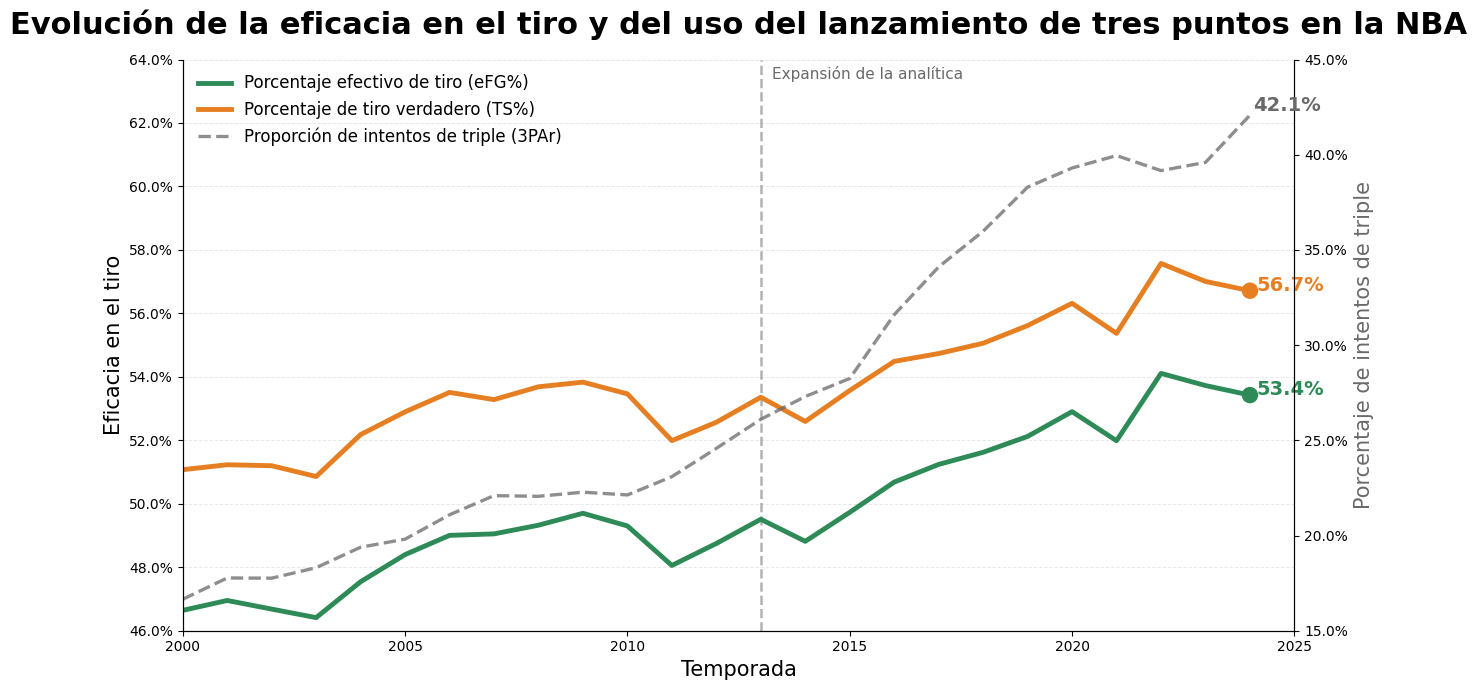

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ======================================================
# League totals by season
# ======================================================

league = (
    nba_master_final
    .groupby("SeasonYear")[["FG", "3P", "3PA", "FGA", "FTA", "PTS"]]
    .sum()
    .reset_index()
)

# ======================================================
# Advanced shooting metrics
# ======================================================

# Effective Field Goal Percentage
league["eFG"] = (
    league["FG"] + 0.5 * league["3P"]
) / league["FGA"]

# True Shooting Percentage
league["TS"] = (
    league["PTS"]
) / (
    2 * (league["FGA"] + 0.44 * league["FTA"])
)

# Three-Point Attempt Rate
league["3PAr"] = (
    league["3PA"] /
    league["FGA"]
)

# ======================================================
# Figure
# ======================================================

fig, ax1 = plt.subplots(figsize=(13,7))

# ------------------------------------------------------
# Highlight modern NBA
# ------------------------------------------------------

ax1.axvline(
    2013,
    color="gray",
    linestyle="--",
    linewidth=1.8,
    alpha=0.6
)

ax1.text(
    2013.25,
    0.638,
    "Expansión de la analítica",
    fontsize=11,
    color="dimgray",
    va="top"
)

# ------------------------------------------------------
# Effective FG%
# ------------------------------------------------------

ax1.plot(
    league["SeasonYear"],
    league["eFG"],
    color="#2E8B57",
    linewidth=3.5,
    label="Porcentaje efectivo de tiro (eFG%)"
)

# ------------------------------------------------------
# True Shooting %
# ------------------------------------------------------

ax1.plot(
    league["SeasonYear"],
    league["TS"],
    color="#E67E22",
    linewidth=3.5,
    label="Porcentaje de tiro verdadero (TS%)"
)

# ------------------------------------------------------
# Highlight last season
# ------------------------------------------------------

ax1.scatter(
    league.iloc[-1]["SeasonYear"],
    league.iloc[-1]["eFG"],
    s=140,
    color="#2E8B57",
    edgecolor="none",
    linewidth=2,
    zorder=5
)

ax1.scatter(
    league.iloc[-1]["SeasonYear"],
    league.iloc[-1]["TS"],
    s=140,
    color="#E67E22",
    edgecolor="none",
    linewidth=2,
    zorder=5
)

# ======================================================
# Secondary axis (3PAr)
# ======================================================

ax2 = ax1.twinx()

ax2.plot(
    league["SeasonYear"],
    league["3PAr"],
    color="dimgray",
    linewidth=2.4,
    linestyle="--",
    label="Proporción de intentos de triple (3PAr)",
    alpha=0.75
)

# ======================================================
# Final values
# ======================================================

ax1.text(
    2024.15,
    league.iloc[-1]["eFG"],
    f"{league.iloc[-1]['eFG']:.1%}",
    color="#2E8B57",
    fontsize=14,
    weight="bold"
)

ax1.text(
    2024.15,
    league.iloc[-1]["TS"],
    f"{league.iloc[-1]['TS']:.1%}",
    color="#E67E22",
    fontsize=14,
    weight="bold"
)

ax2.text(
    2024.08,
    league.iloc[-1]["3PAr"]+0.002,
    f"{league.iloc[-1]['3PAr']:.1%}",
    color="dimgray",
    fontsize=14,
    weight="bold"
)

# ======================================================
# Labels
# ======================================================

ax1.set_title(
    "Evolución de la eficacia en el tiro y del uso del lanzamiento de tres puntos en la NBA",
    fontsize=22,
    weight="bold",
    pad=18
)

ax1.set_xlabel(
    "Temporada",
    fontsize=15
)

ax1.set_ylabel(
    "Eficacia en el tiro",
    fontsize=15
)

ax2.set_ylabel(
    "Porcentaje de intentos de triple",
    fontsize=15,
    color="dimgray"
)

# ======================================================
# Percent formatting
# ======================================================

ax1.yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

ax2.yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

# ======================================================
# Limits
# ======================================================

ax1.set_xlim(2000, 2025)

ax1.set_ylim(0.46, 0.64)

ax2.set_ylim(0.15, 0.45)

# ======================================================
# Grid
# ======================================================

ax1.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.18,
    color="gray"
)

ax1.grid(axis="x", visible=False)
ax2.grid(False)

# ======================================================
# Legend
# ======================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    fontsize=12,
    loc="upper left"
)

sns.despine(right=False)

plt.tight_layout()

plt.show()

La Figura 4.7 evidencia una evolución paralela entre el aumento del uso del tiro de tres puntos y la mejora de la eficiencia ofensiva en la NBA. A medida que el 3PAr aumentó del 17% al 42% entre 2000 y 2024, tanto el eFG% como el TS% registraron incrementos sostenidos, lo que sugiere que la transformación en la selección de tiro ha contribuido a una mayor eficiencia anotadora.

## 4.8 — eFG% por posición. ¿Qué posiciones han experimentado la mayor mejora en eficiencia? 

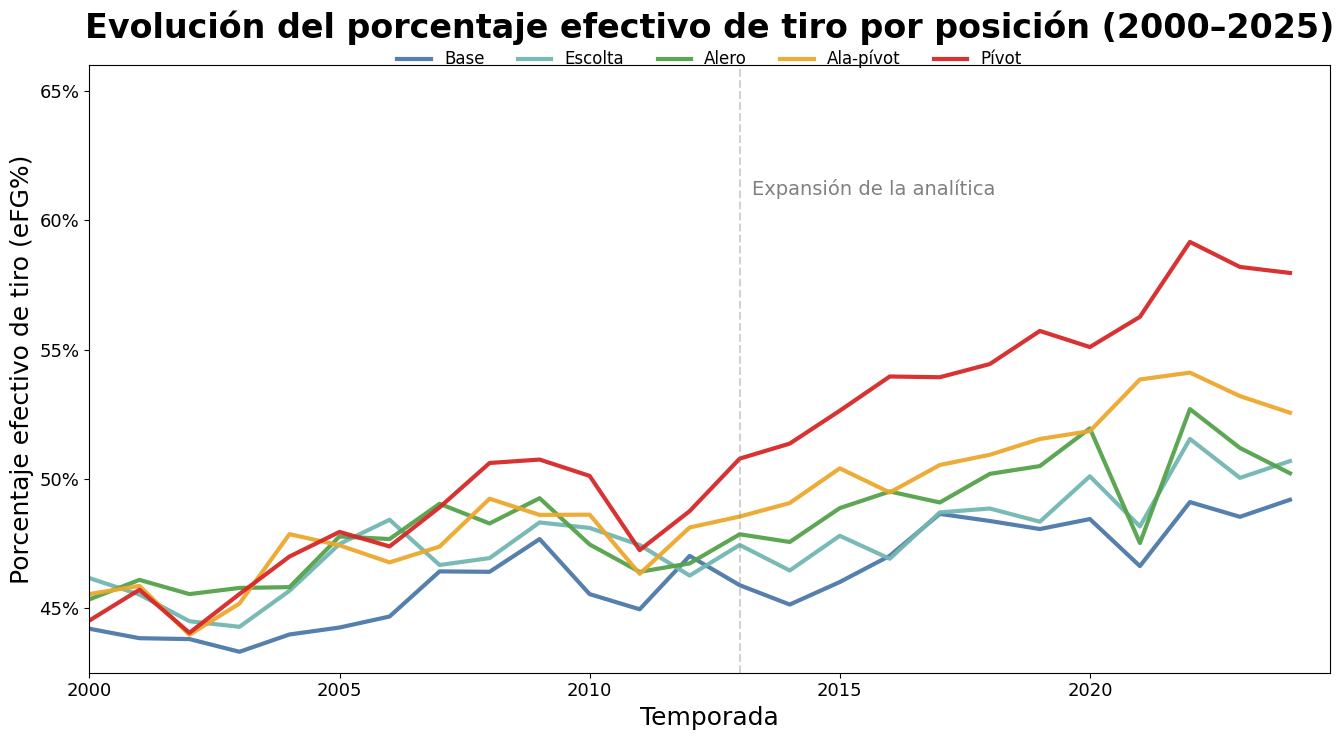

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# Average eFG% by Position and Season
# ======================================================

efg_pos = (
    nba_master_final
    .groupby(["SeasonYear", "Pos"])["eFG%_tot"]
    .mean()
    .reset_index()
)

# ======================================================
# Colors (same style as Figure 4.5)
# ======================================================

colors = {
    "PG": "#4C78A8",   # Azul
    "SG": "#72B7B2",   # Turquesa
    "SF": "#54A24B",   # Verde
    "PF": "#ECA82C",   # Naranja
    "C":  "#D62728"    # Rojo
}

linewidths = {
    "PG": 2.5,
    "SG": 2.5,
    "SF": 2.5,
    "PF": 3.0,
    "C": 3.2
}

alphas = {
    "PG": 0.90,
    "SG": 0.90,
    "SF": 0.90,
    "PF": 0.95,
    "C": 1.00
}

# ======================================================
# Plot
# ======================================================

plt.figure(figsize=(13.5, 7.5))

for pos in ["PG", "SG", "SF", "PF", "C"]:

    data = efg_pos.loc[
        efg_pos["Pos"] == pos
    ]

    plt.plot(
        data["SeasonYear"],
        data["eFG%_tot"],
        color=colors[pos],
        linewidth=3,
        alpha=0.95
    )

# ======================================================
# Analytics era
# ======================================================

plt.axvline(
    2013,
    color="gray",
    linestyle="--",
    alpha=0.35
)

plt.text(
    2013.25,
    0.61,
    "Expansión de la analítica",
    fontsize=14,
    color="gray"
)

# ======================================================
# Formatting
# ======================================================

plt.title(
    "Evolución del porcentaje efectivo de tiro por posición (2000–2025)",
    fontsize=24,
    weight="bold",
    pad=20
)

plt.xlabel(
    "Temporada",
    fontsize=18
)

plt.ylabel(
    "Porcentaje efectivo de tiro (eFG%)",
    fontsize=18
)

plt.xlim(2000, 2024.8)

plt.ylim(0.425, 0.66)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{100*y:.0f}%")
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.grid(False)

plt.legend(
    ["Base", "Escolta", "Alero", "Ala-pívot", "Pívot"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=5,
    frameon=False,
    fontsize=12
)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.tight_layout()

plt.show()

La Figura 4.8 muestra la evolución del Effective Field Goal Percentage (eFG%) por posición entre 2000 y 2024. Aunque todas las posiciones registran una mejora gradual en la eficiencia ofensiva, el incremento es especialmente pronunciado en los jugadores interiores. Los centers presentan la mayor evolución, alcanzando los valores más altos de eFG% al final del periodo, mientras que los power forwards también experimentan una mejora notable. Estos resultados sugieren que la transformación en la selección de tiro de los interiores ha estado acompañada de un aumento significativo de su eficiencia ofensiva.

## 4.9. Relación entre el porcentaje de intentos de triples y el porcentaje efectivo de tiros de campo

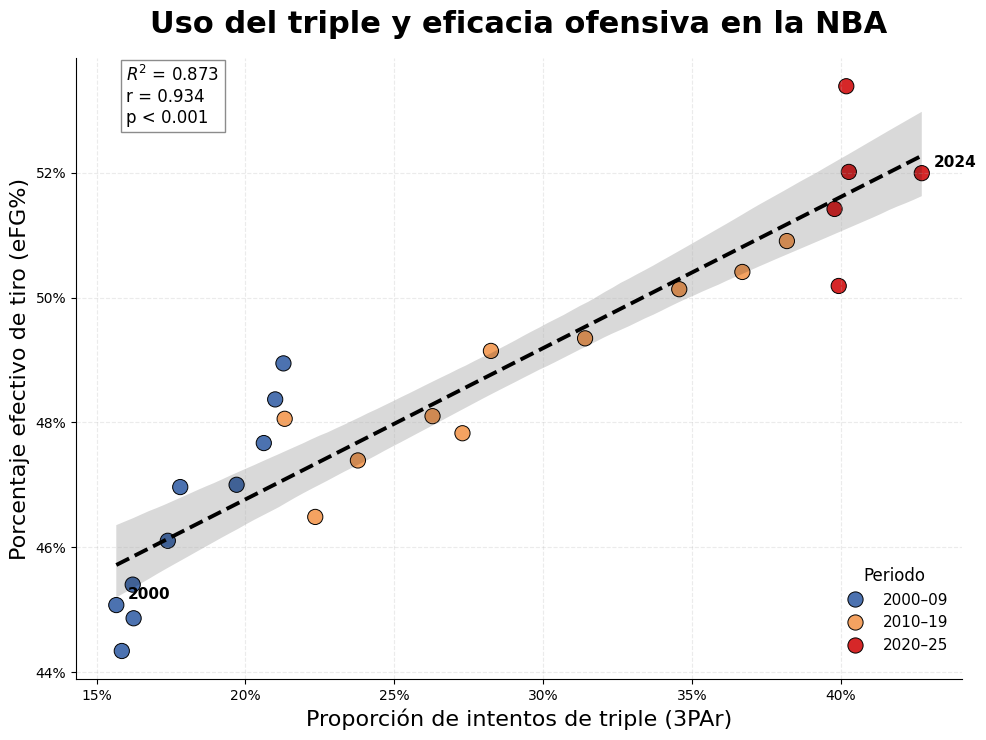

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# ======================================================
# League averages by season
# ======================================================

league = (
    nba_master_final
    .groupby("SeasonYear")
    .agg(
        ThreePAr=("3PAr", "mean"),
        eFG=("eFG%_tot", "mean")
    )
    .reset_index()
)

# ======================================================
# NBA Eras
# ======================================================

league["Era"] = pd.cut(
    league["SeasonYear"],
    bins=[1999, 2009, 2019, 2025],
    labels=["2000–09", "2010–19", "2020–25"]
)

# ======================================================
# Linear regression
# ======================================================

slope, intercept, r, p, stderr = linregress(
    league["ThreePAr"],
    league["eFG"]
)

r2 = r**2

# ======================================================
# Colors
# ======================================================

palette = {
    "2000–09": "#4C72B0",
    "2010–19": "#F4A261",
    "2020–25": "#D62728"
}

# ======================================================
# Figure
# ======================================================

plt.figure(figsize=(10,7.5))

# Scatter
sns.scatterplot(
    data=league,
    x="ThreePAr",
    y="eFG",
    hue="Era",
    palette=palette,
    s=120,
    edgecolor="black",
    linewidth=0.7
)

# Regression
sns.regplot(
    data=league,
    x="ThreePAr",
    y="eFG",
    scatter=False,
    color="black",
    ci=95,
    line_kws={
        "linewidth":2.8,
        "linestyle":"--"
    }
)

# ======================================================
# Label first and last seasons
# ======================================================

for year in [2000, 2024]:

    row = league.loc[
        league["SeasonYear"] == year
    ].iloc[0]

    plt.text(
        row["ThreePAr"] + 0.004,
        row["eFG"] + 0.001,
        str(year),
        fontsize=11,
        weight="bold"
    )

# ======================================================
# Correlation statistics
# ======================================================

plt.text(
    0.16, 0.528,
    f"$R^2$ = {r2:.3f}\n"
    f"r = {r:.3f}\n"
    f"p < 0.001",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="gray", alpha=.9)
)

# ======================================================
# Annotation
# ======================================================

plt.annotate(
    "Greater reliance on three-point shooting\nis associated with higher shooting efficiency",
    xy=(0.37,0.545),
    xytext=(0.23,0.585),
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5,
        color="gray"
    ),
    fontsize=12,
    color="dimgray"
)

# ======================================================
# Titles
# ======================================================

plt.title(
    "Uso del triple y eficacia ofensiva en la NBA",
    fontsize=22,
    weight="bold",
    pad=18
)

plt.xlabel(
    "Proporción de intentos de triple (3PAr)",
    fontsize=16
)

plt.ylabel(
    "Porcentaje efectivo de tiro (eFG%)",
    fontsize=16
)

# ======================================================
# Percent axes
# ======================================================

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f"{100*x:.0f}%")
)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y,_: f"{100*y:.0f}%")
)

# ======================================================
# Grid
# ======================================================

plt.grid(
    linestyle="--",
    alpha=0.25
)

plt.legend(
    title="Periodo",
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    loc="lower right",
    bbox_to_anchor=(1.00,0.02)
)

sns.despine()

plt.tight_layout()

plt.show()

Figura 4.9 muestra una fuerte relación positiva entre el porcentaje de lanzamientos desde la línea de tres (3PAr) y el porcentaje efectivo de tiro (eFG%). A medida que la NBA incrementó el volumen relativo de triples, la eficiencia ofensiva también aumentó de forma consistente. La correlación observada es muy elevada (r = 0.934; R² = 0.873; p < 0.001), lo que indica que el incremento del uso del triple estuvo estrechamente asociado con la mejora de la eficiencia en el lanzamiento durante el periodo analizado.

## 4.10 Correlación de los indicadores de rendimiento con el salario

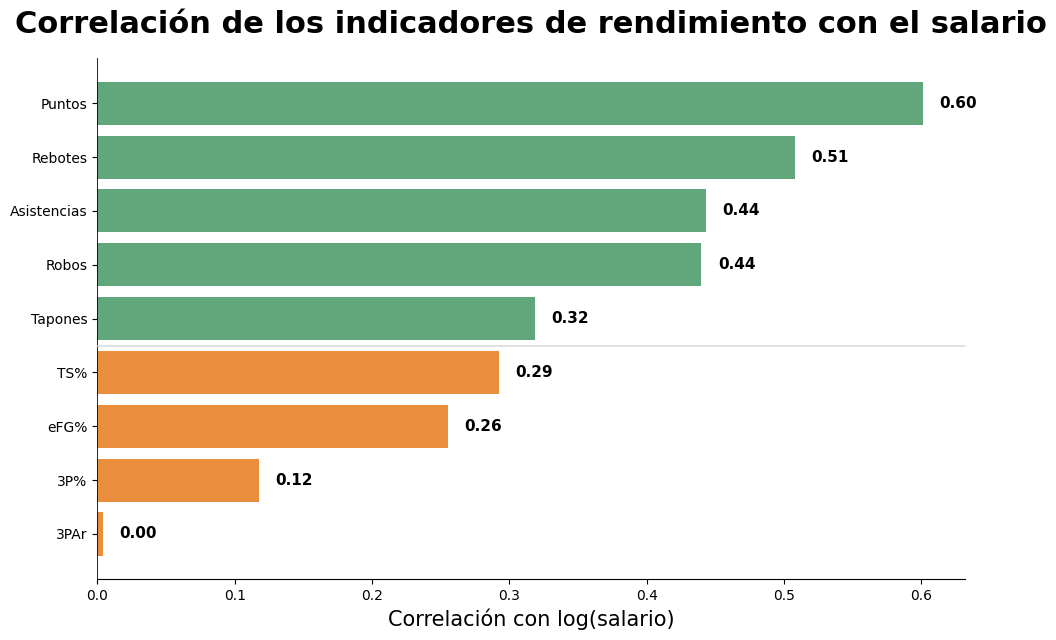

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# Preparación de datos
# ======================================================

# Logaritmo del salario
nba_master_final["LogSalary"] = np.log1p(nba_master_final["Salary"])

# Variables de interés
variables = [
    "3PAr",
    "3P%",
    "eFG%",
    "TS%",
    "PTS",
    "AST",
    "TRB",
    "STL",
    "BLK"
]

# Mantener únicamente las variables existentes
variables = [v for v in variables if v in nba_master_final.columns]

# ======================================================
# Correlaciones con el salario
# ======================================================

corrs = []

for var in variables:

    temp = nba_master_final[[var, "LogSalary"]].dropna()

    r = temp[var].corr(temp["LogSalary"])

    corrs.append([var, r])

corr_df = (
    pd.DataFrame(corrs, columns=["Metric", "Correlation"])
      .sort_values("Correlation")
)

# ======================================================
# Colores
# ======================================================

shooting_metrics = ["TS%", "eFG%", "3P%", "3PAr"]

colors = [
    "#E67E22" if metric in shooting_metrics else "#4C9A6A"
    for metric in corr_df["Metric"]
]

# ======================================================
# Traducir etiquetas
# ======================================================

labels = {
    "PTS": "Puntos",
    "TRB": "Rebotes",
    "AST": "Asistencias",
    "STL": "Robos",
    "BLK": "Tapones",
    "TS%": "TS%",
    "eFG%": "eFG%",
    "3P%": "3P%",
    "3PAr": "3PAr"
}

corr_df["Etiqueta"] = corr_df["Metric"].map(labels)

# ======================================================
# Figura
# ======================================================

plt.figure(figsize=(10,6.5))

bars = plt.barh(
    corr_df["Etiqueta"],
    corr_df["Correlation"],
    color=colors,
    alpha=0.88
)

# Línea vertical en 0
plt.axvline(
    0,
    color="black",
    linewidth=1.2
)

# Etiquetas de las barras
for bar in bars:

    value = bar.get_width()

    plt.text(
        value + (0.012 if value >= 0 else -0.012),
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        ha="left" if value >= 0 else "right",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# ======================================================
# Estilo
# ======================================================

plt.title(
    "Correlación de los indicadores de rendimiento con el salario",
    fontsize=22,
    weight="bold",
    pad=18
)

plt.xlabel(
    "Correlación con log(salario)",
    fontsize=15
)

plt.ylabel("")

plt.axhline(
    y=3.5,
    color="lightgray",
    linewidth=1.2,
    alpha=0.8
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.grid(False)

sns.despine(left=True)

plt.tight_layout()

plt.show()

Figura 4.10. Los resultados indican que el salario de los jugadores está más relacionado con su producción estadística (especialmente puntos, rebotes y asistencias) que con el volumen de triples intentados. Aunque la eficiencia de tiro mantiene una correlación positiva, el porcentaje de tiros lanzados desde la línea de tres puntos (3PAr) apenas presenta relación con la remuneración económica.

## 4.11. Factores que determinan el salario en la NBA: regresión lineal múltiple

In [44]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import numpy as np
import pandas as pd

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

Probamos primero con bastantes variables

In [47]:
# Variables
variables = [
    "PTS",
    "AST",
    "TRB",
    "STL",
    "BLK",
    "TS%",
    "eFG%_tot",
    "3P%",
    "3PAr",
    "Age",
    "MP",
    "PER",
    "WS"
]

In [48]:
# Dataframe
salary_df = nba_master_final[
    variables + ["Salary"]
].copy()

salary_df = salary_df.dropna()

salary_df["LogSalary"] = np.log1p(
    salary_df["Salary"]
)

In [49]:
# Estandarizar las variables
scaler = StandardScaler()

X = scaler.fit_transform(
    salary_df[variables]
)

X = pd.DataFrame(
    X,
    columns=variables
)

y = StandardScaler().fit_transform(
    salary_df[["LogSalary"]]
).ravel()

In [50]:
# Ajustar el modelo
X = sm.add_constant(X)

model = sm.OLS(
    y,
    X
).fit()

In [51]:
# Extraer resultados
results = pd.DataFrame({

    "Variable": model.params.index,

    "Beta": model.params.values,

    "Lower": model.conf_int()[0],

    "Upper": model.conf_int()[1],

    "p": model.pvalues

})

results = results.query(
    "Variable!='const'"
)

results = results.sort_values(
    "Beta"
)

In [52]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.510
Method:                 Least Squares   F-statistic:                     809.1
Date:                Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:10:12   Log-Likelihood:                -10697.
No. Observations:               10080   AIC:                         2.142e+04
Df Residuals:                   10066   BIC:                         2.152e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.026e-15      0.007  -2.91e-13      1.0

### Calculamos el VIF (Variance Inflation Factor).

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [54]:
variables = [
    "PTS",
    "AST",
    "TRB",
    "STL",
    "BLK",
    "TS%",
    "eFG%_tot",
    "3P%",
    "3PAr",
    "Age",
    "MP"
]

X = salary_df[variables].copy()

In [55]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

    Variable         VIF
5        TS%  518.148213
6   eFG%_tot  457.863515
10        MP   42.599442
9        Age   26.052459
0        PTS   16.482255
2        TRB   12.558470
3        STL    9.495732
7        3P%    7.626300
1        AST    5.785862
8       3PAr    4.563834
4        BLK    4.011895


No solo existe colinealidad entre TS% y eFG%, que era esperable. También ocurre algo más importante:

PTS depende en gran medida de MP (quien juega más minutos suele anotar más).
Age está muy relacionado con el salario debido a la estructura contractual de la NBA (los veteranos suelen haber firmado contratos mayores).
TS%, eFG% y 3P% describen prácticamente el mismo concepto: eficiencia ofensiva.

En consecuencia, el modelo intenta repartir la explicación del salario entre variables muy parecidas y los coeficientes β dejan de ser estables.

### Quitamos algunas variables problemáticas, como los minutos jugados y el eFG%, ya que es una métrica que ya se ha analizado previamente en varios apartados.
### Eliminamos también la edad, debido a que refleja experiencia y reglas contractuales más que rendimiento deportivo. Por lo tanto, nos quedamos con:
- PTS → producción ofensiva.
- AST → creación de juego.
- TRB → presencia interior.
- BLK → impacto defensivo.
- 3PAr → adaptación al baloncesto moderno (una de nuestras variables de interés).
- 3P% → eficacia en el lanzamiento exterior (otra variable de interés).

## OPCIÓN 1: Modelo con foco en las métricas de tiro de 3

In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = [
    "PTS",
    "AST",
    "TRB",
    "BLK",
    "3P%",
    "3PAr"
]

X = salary_df[variables].copy()

In [57]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

  Variable       VIF
0      PTS  9.736300
2      TRB  8.835392
4      3P%  5.448254
1      AST  4.301217
3      BLK  3.938397
5     3PAr  3.503718


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     1130.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:10:13   Log-Likelihood:                -11708.
No. Observations:               10080   AIC:                         2.343e+04
Df Residuals:                   10073   BIC:                         2.348e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.637e-16      0.008  -3.42e-14      1.0

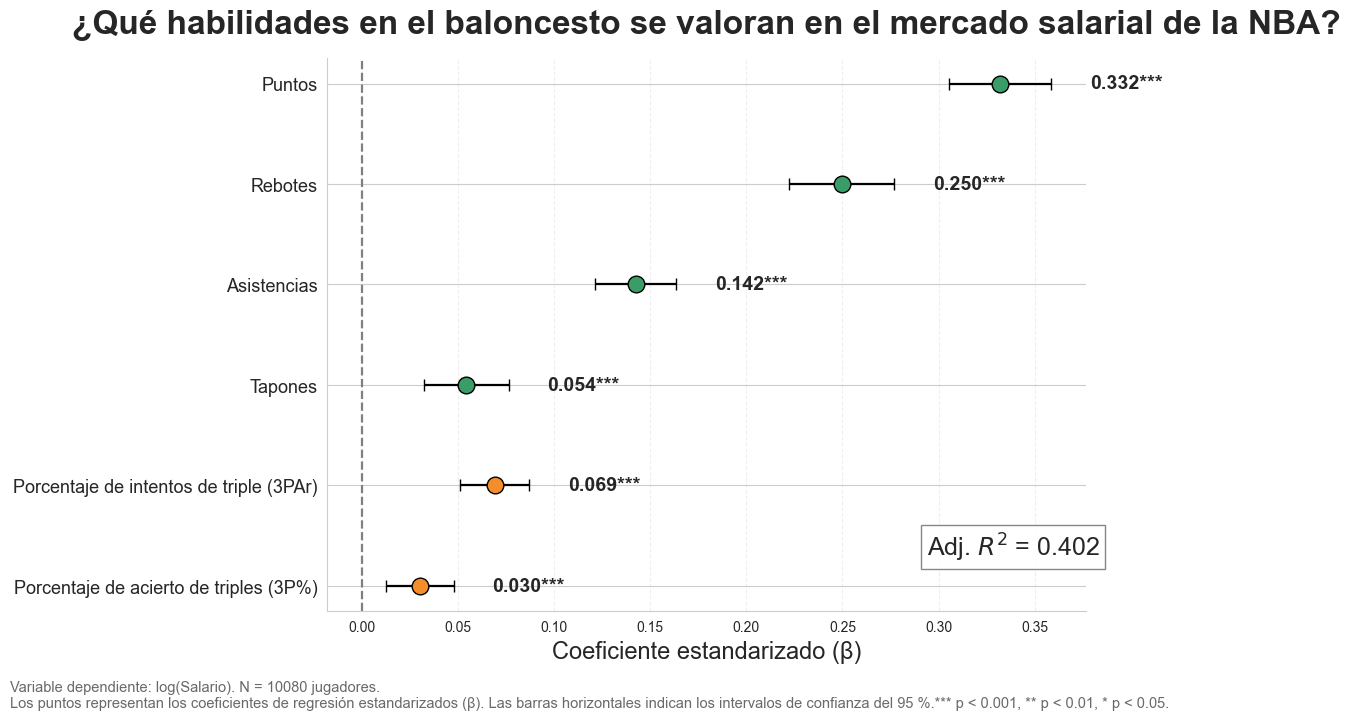

In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler

# ======================================================
# Variables
# ======================================================

variables = [
    "PTS",
    "AST",
    "TRB",
    "BLK",
    "3PAr",
    "3P%"
]

# ======================================================
# Dataset
# ======================================================

df = (
    nba_master_final[
        variables + ["Salary"]
    ]
    .dropna()
    .copy()
)

# ======================================================
# Dependent variable
# ======================================================

df["LogSalary"] = np.log(df["Salary"])

# ======================================================
# Standardization
# ======================================================

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(df[variables]),
    columns=variables
)

y = StandardScaler().fit_transform(
    df[["LogSalary"]]
).ravel()

# ======================================================
# Multiple linear regression
# ======================================================

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

# ======================================================
# Results
# ======================================================

coef = model.params.drop("const")
ci = model.conf_int().drop("const")
pvalues = model.pvalues.drop("const")

results = pd.DataFrame({

    "Variable": coef.index,
    "Beta": coef.values,
    "Lower": ci[0].values,
    "Upper": ci[1].values,
    "p": pvalues.values

})

# ======================================================
# Labels
# ======================================================

labels = {

    "PTS": "Puntos",
    "TRB": "Rebotes",
    "AST": "Asistencias",
    "3PAr": "Porcentaje de intentos de triple (3PAr)",
    "3P%": "Porcentaje de acierto de triples (3P%)",
    "BLK": "Tapones"

}

results["Label"] = results["Variable"].map(labels)

# ======================================================
# Manual order
# ======================================================

order = [

    "Puntos",
    "Rebotes",
    "Asistencias",
    "Tapones",
    "Porcentaje de intentos de triple (3PAr)",
    "Porcentaje de acierto de triples (3P%)"

]

results["Label"] = pd.Categorical(
    results["Label"],
    categories=order,
    ordered=True
)

results = results.sort_values("Label")

# ======================================================
# Colors
# ======================================================

color_map = {

    "Puntos": "#3A9D68",
    "Rebotes": "#3A9D68",
    "Asistencias": "#3A9D68",

    "Porcentaje de intentos de triple (3PAr)": "#F28E2B",

    "Porcentaje de acierto de triples (3P%)": "#F28E2B",

    "Tapones": "#3A9D68"

}

# ======================================================
# Figure
# ======================================================

sns.set_style("whitegrid")

fig, ax = plt.subplots(
    figsize=(11.8,7.2)
)

# ======================================================
# Zero line
# ======================================================

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.6
)

# ======================================================
# Forest plot
# ======================================================

for i, row in enumerate(results.itertuples()):

    color = color_map[row.Label]

    ax.errorbar(

        row.Beta,

        i,

        xerr=[
            [row.Beta-row.Lower],
            [row.Upper-row.Beta]
        ],

        fmt="o",

        color=color,

        markeredgecolor="black",

        markersize=12,

        ecolor="black",

        elinewidth=1.6,

        capsize=4

    )

    # Significance

    if row.p < 0.001:
        stars="***"

    elif row.p < 0.01:
        stars="**"

    elif row.p < 0.05:
        stars="*"

    else:
        stars=""

    ax.text(

        row.Upper + 0.02,

        i,

        f"{row.Beta:.3f}{stars}",

        fontsize=14,

        fontweight="bold",

        va="center"

    )

# ======================================================
# Axis
# ======================================================

ax.set_yticks(range(len(results)))

ax.set_yticklabels(
    results["Label"],
    fontsize=13
)

ax.invert_yaxis()

ax.set_xlabel(

    "Coeficiente estandarizado (β)",

    fontsize=17

)

ax.set_ylabel("")

# ======================================================
# Grid
# ======================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

sns.despine()

# ======================================================
# Adj R²
# ======================================================

ax.text(

    0.79,

    0.10,

    f"Adj. $R^2$ = {model.rsquared_adj:.3f}",

    transform=ax.transAxes,

    fontsize=18,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        alpha=.95

    )

)

# ======================================================
# Title
# ======================================================

plt.title(

    "¿Qué habilidades en el baloncesto se valoran en el mercado salarial de la NBA?",

    fontsize=24,

    weight="bold",

    pad=18

)

# ======================================================
# Footnote
# ======================================================

plt.figtext(

    0.01,

    0.01,

    f"Variable dependiente: log(Salario). N = {len(df)} jugadores.\n"
    "Los puntos representan los coeficientes de regresión estandarizados (β). "
    "Las barras horizontales indican los intervalos de confianza del 95 %."
    "*** p < 0.001, ** p < 0.01, * p < 0.05.",

    fontsize=10.5,

    color="dimgray"

)

plt.tight_layout(
    rect=[0,0.05,1,1]
)

plt.show()

✅ todos los coeficientes son significativos (p < 0.001)

Este último punto es muy importante: todas las variables aportan información adicional.

Como hemos estandarizado todas las variables, los coeficientes β son directamente comparables.

Variable	β	Interpretación
- PTS	0.332	Predictor más importante del salario
- TRB	0.25	Segundo predictor más relevante
- AST	0.142	La creación de juego también incrementa el salario
- 3PAr	0.069	El tiro exterior moderno tiene un efecto positivo e independiente
- BLK	0.054	La protección del aro también aporta valor económico
- 3P%   0.030   El acierto en el tiro exterior tiene cierto efecto, pero es inferior al volumen de tiro de 3

3PAr y 3P% sigueN siendo estadísticamente significativo incluso después de controlar por puntos, asistencias, rebotes y tapones.

No se paga únicamente producir más; también se recompensa el perfil de jugador adaptado al baloncesto moderno.

R² = 0.402

Un R² del 40,2% puede parecer "moderado", pero en realidad es muy razonable para un modelo salarial.

El salario depende de muchos factores que no aparecen en la base de datos:

antigüedad en la liga,
agencia libre,
mercado de la franquicia,
potencial futuro,
lesiones,
liderazgo,
marketing,
contratos máximos,
convenios colectivos...

Por tanto, explicar un 40% de la variabilidad únicamente con estadísticas deportivas es un buen resultado.

## OPCIÓN 2: Modelo mejorado

In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = [
    "PTS",
    "AST",
    "TRB",
    "BLK",
    "3P%",
    "3PAr",
    "Age",
    "MP",
    "PER"
]

X = salary_df[variables].copy()

In [60]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

  Variable        VIF
7       MP  38.382906
0      PTS  20.089334
8      PER  18.041277
6      Age  15.859096
2      TRB  12.972891
4      3P%   7.335555
1      AST   5.205987
5     3PAr   4.738205
3      BLK   4.073718


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     1122.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:10:14   Log-Likelihood:                -10803.
No. Observations:               10080   AIC:                         2.163e+04
Df Residuals:                   10070   BIC:                         2.170e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.637e-16      0.007  -3.74e-14      1.0

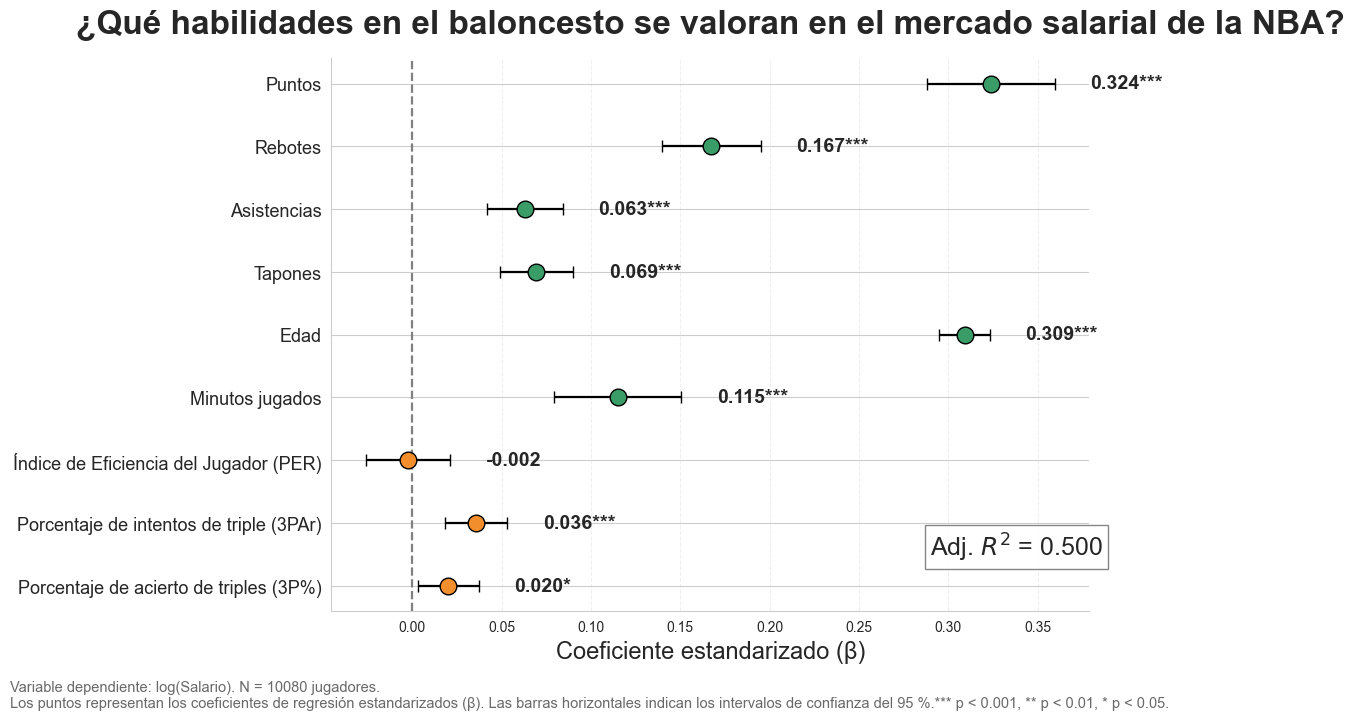

In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler

# ======================================================
# Variables
# ======================================================

variables = [
    "PTS",
    "AST",
    "TRB",
    "BLK",
    "3PAr",
    "3P%",
    "Age",
    "MP",
    "PER"
    
]

# ======================================================
# Dataset
# ======================================================

df = (
    nba_master_final[
        variables + ["Salary"]
    ]
    .dropna()
    .copy()
)

# ======================================================
# Dependent variable
# ======================================================

df["LogSalary"] = np.log(df["Salary"])

# ======================================================
# Standardization
# ======================================================

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(df[variables]),
    columns=variables
)

y = StandardScaler().fit_transform(
    df[["LogSalary"]]
).ravel()

# ======================================================
# Multiple linear regression
# ======================================================

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

# ======================================================
# Results
# ======================================================

coef = model.params.drop("const")
ci = model.conf_int().drop("const")
pvalues = model.pvalues.drop("const")

results = pd.DataFrame({

    "Variable": coef.index,
    "Beta": coef.values,
    "Lower": ci[0].values,
    "Upper": ci[1].values,
    "p": pvalues.values

})

# ======================================================
# Labels
# ======================================================

labels = {

    "PTS": "Puntos",
    "TRB": "Rebotes",
    "AST": "Asistencias",
    "3PAr": "Porcentaje de intentos de triple (3PAr)",
    "3P%": "Porcentaje de acierto de triples (3P%)",
    "BLK": "Tapones",
    "Age": "Edad",
    "MP": "Minutos jugados",
    "PER": "Índice de Eficiencia del Jugador (PER)"

}

results["Label"] = results["Variable"].map(labels)

# ======================================================
# Manual order
# ======================================================

order = [

    "Puntos",
    "Rebotes",
    "Asistencias",
    "Tapones",
    "Edad",
    "Minutos jugados",
    "Índice de Eficiencia del Jugador (PER)",
    "Porcentaje de intentos de triple (3PAr)",
    "Porcentaje de acierto de triples (3P%)"
]

results["Label"] = pd.Categorical(
    results["Label"],
    categories=order,
    ordered=True
)

results = results.sort_values("Label")

# ======================================================
# Colors
# ======================================================

color_map = {

    "Puntos": "#3A9D68",
    "Rebotes": "#3A9D68",
    "Asistencias": "#3A9D68",
    "Edad": "#3A9D68",
    "Minutos jugados": "#3A9D68",
    "Tapones": "#3A9D68",

    "Índice de Eficiencia del Jugador (PER)": "#F28E2B",
    "Porcentaje de intentos de triple (3PAr)": "#F28E2B",
    "Porcentaje de acierto de triples (3P%)": "#F28E2B",
    

}

# ======================================================
# Figure
# ======================================================

sns.set_style("whitegrid")

fig, ax = plt.subplots(
    figsize=(11.8,7.2)
)

# ======================================================
# Zero line
# ======================================================

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.6
)

# ======================================================
# Forest plot
# ======================================================

for i, row in enumerate(results.itertuples()):

    color = color_map[row.Label]

    ax.errorbar(

        row.Beta,

        i,

        xerr=[
            [row.Beta-row.Lower],
            [row.Upper-row.Beta]
        ],

        fmt="o",

        color=color,

        markeredgecolor="black",

        markersize=12,

        ecolor="black",

        elinewidth=1.6,

        capsize=4

    )

    # Significance

    if row.p < 0.001:
        stars="***"

    elif row.p < 0.01:
        stars="**"

    elif row.p < 0.05:
        stars="*"

    else:
        stars=""

    ax.text(

        row.Upper + 0.02,

        i,

        f"{row.Beta:.3f}{stars}",

        fontsize=14,

        fontweight="bold",

        va="center"

    )

# ======================================================
# Axis
# ======================================================

ax.set_yticks(range(len(results)))

ax.set_yticklabels(
    results["Label"],
    fontsize=13
)

ax.invert_yaxis()

ax.set_xlabel(

    "Coeficiente estandarizado (β)",

    fontsize=17

)

ax.set_ylabel("")

# ======================================================
# Grid
# ======================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

sns.despine()

# ======================================================
# Adj R²
# ======================================================

ax.text(

    0.79,

    0.10,

    f"Adj. $R^2$ = {model.rsquared_adj:.3f}",

    transform=ax.transAxes,

    fontsize=18,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        alpha=.95

    )

)

# ======================================================
# Title
# ======================================================

plt.title(

    "¿Qué habilidades en el baloncesto se valoran en el mercado salarial de la NBA?",

    fontsize=24,

    weight="bold",

    pad=18

)

# ======================================================
# Footnote
# ======================================================

plt.figtext(

    0.01,

    0.01,

    f"Variable dependiente: log(Salario). N = {len(df)} jugadores.\n"
    "Los puntos representan los coeficientes de regresión estandarizados (β). "
    "Las barras horizontales indican los intervalos de confianza del 95 %."
    "*** p < 0.001, ** p < 0.01, * p < 0.05.",

    fontsize=10.5,

    color="dimgray"

)

plt.tight_layout(
    rect=[0,0.05,1,1]
)

plt.show()

Se estimó un modelo alternativo incorporando edad, minutos jugados y PER. Aunque el poder explicativo aumentó hasta un R2 ajustado de 0.50, el PER dejó de ser estadísticamente significativo y se observaron elevados niveles de multicolinealidad (VIF > 10), por lo que se optó por mantener el modelo anterior.

## OPCIÓN 3

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = [
    "PTS",
    "AST",
    "TRB",
    "BLK",
    "3P%",
    "3PAr",
    "Age",
    "MP"
]

X = salary_df[variables].copy()

In [63]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

  Variable        VIF
7       MP  34.936331
0      PTS  15.642723
2      TRB  12.211454
6      Age  10.990921
4      3P%   6.434148
1      AST   5.049839
5     3PAr   4.440474
3      BLK   3.951239


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     1262.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:10:14   Log-Likelihood:                -10803.
No. Observations:               10080   AIC:                         2.162e+04
Df Residuals:                   10071   BIC:                         2.169e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.637e-16      0.007  -3.74e-14      1.0

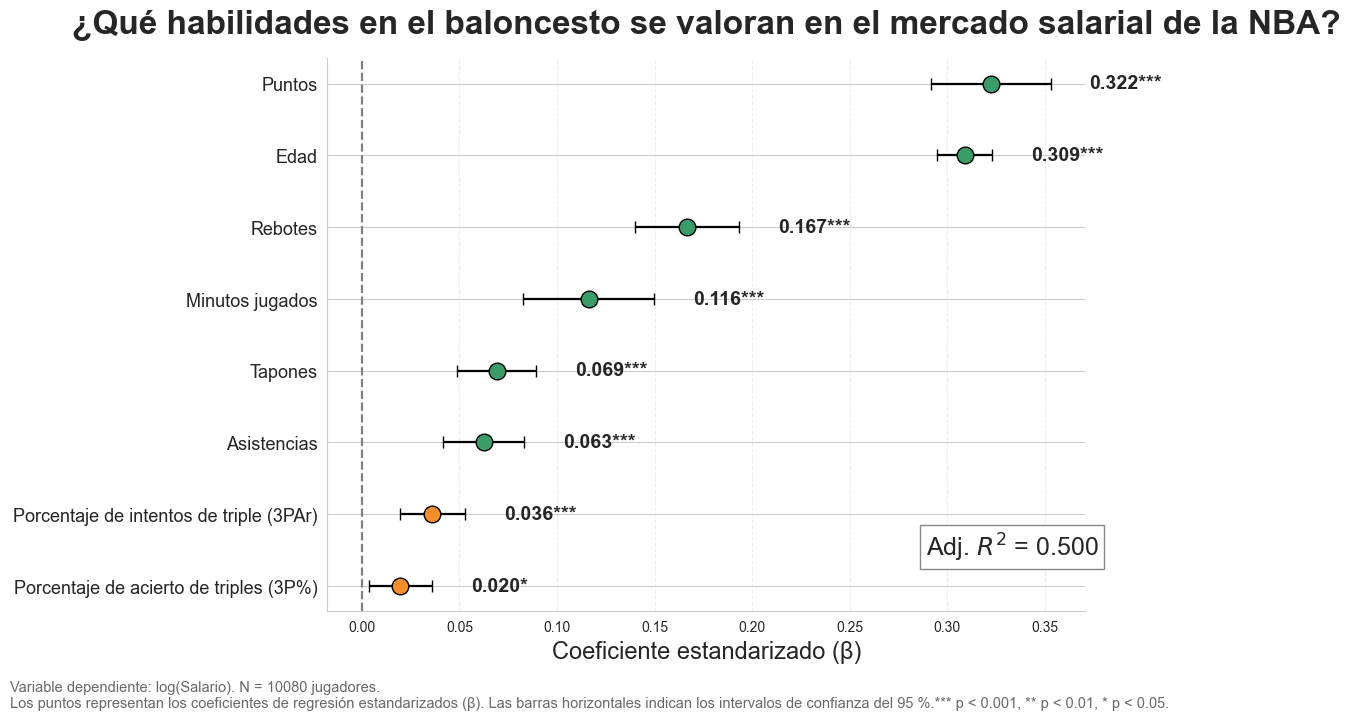

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler

# ======================================================
# Variables
# ======================================================

variables = [
    "PTS",
    "AST",
    "TRB",
    "BLK",
    "3PAr",
    "3P%",
    "Age",
    "MP"
]

# ======================================================
# Dataset
# ======================================================

df = (
    nba_master_final[
        variables + ["Salary"]
    ]
    .dropna()
    .copy()
)

# ======================================================
# Dependent variable
# ======================================================

df["LogSalary"] = np.log(df["Salary"])

# ======================================================
# Standardization
# ======================================================

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(df[variables]),
    columns=variables
)

y = StandardScaler().fit_transform(
    df[["LogSalary"]]
).ravel()

# ======================================================
# Multiple linear regression
# ======================================================

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

# ======================================================
# Results
# ======================================================

coef = model.params.drop("const")
ci = model.conf_int().drop("const")
pvalues = model.pvalues.drop("const")

results = pd.DataFrame({

    "Variable": coef.index,
    "Beta": coef.values,
    "Lower": ci[0].values,
    "Upper": ci[1].values,
    "p": pvalues.values

})

# ======================================================
# Labels
# ======================================================

labels = {

    "PTS": "Puntos",
    "TRB": "Rebotes",
    "AST": "Asistencias",
    "3PAr": "Porcentaje de intentos de triple (3PAr)",
    "3P%": "Porcentaje de acierto de triples (3P%)",
    "BLK": "Tapones",
    "Age": "Edad",
    "MP": "Minutos jugados"
}

results["Label"] = results["Variable"].map(labels)

# ======================================================
# Manual order
# ======================================================

order = [

    "Puntos",
    "Edad",
    "Rebotes",
    "Minutos jugados",
    "Tapones",
    "Asistencias",
    "Porcentaje de intentos de triple (3PAr)",
    "Porcentaje de acierto de triples (3P%)",
    
    
]

results["Label"] = pd.Categorical(
    results["Label"],
    categories=order,
    ordered=True
)

results = results.sort_values("Label")

# ======================================================
# Colors
# ======================================================

color_map = {

    "Puntos": "#3A9D68",
    "Rebotes": "#3A9D68",
    "Asistencias": "#3A9D68",
    "Tapones": "#3A9D68",
    "Porcentaje de intentos de triple (3PAr)": "#F28E2B",
    "Porcentaje de acierto de triples (3P%)": "#F28E2B",
    "Edad": "#3A9D68",
    "Minutos jugados": "#3A9D68"
}

# ======================================================
# Figure
# ======================================================

sns.set_style("whitegrid")

fig, ax = plt.subplots(
    figsize=(11.8,7.2)
)

# ======================================================
# Zero line
# ======================================================

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.6
)

# ======================================================
# Forest plot
# ======================================================

for i, row in enumerate(results.itertuples()):

    color = color_map[row.Label]

    ax.errorbar(

        row.Beta,

        i,

        xerr=[
            [row.Beta-row.Lower],
            [row.Upper-row.Beta]
        ],

        fmt="o",

        color=color,

        markeredgecolor="black",

        markersize=12,

        ecolor="black",

        elinewidth=1.6,

        capsize=4

    )

    # Significance

    if row.p < 0.001:
        stars="***"

    elif row.p < 0.01:
        stars="**"

    elif row.p < 0.05:
        stars="*"

    else:
        stars=""

    ax.text(

        row.Upper + 0.02,

        i,

        f"{row.Beta:.3f}{stars}",

        fontsize=14,

        fontweight="bold",

        va="center"

    )

# ======================================================
# Axis
# ======================================================

ax.set_yticks(range(len(results)))

ax.set_yticklabels(
    results["Label"],
    fontsize=13
)

ax.invert_yaxis()

ax.set_xlabel(

    "Coeficiente estandarizado (β)",

    fontsize=17

)

ax.set_ylabel("")

# ======================================================
# Grid
# ======================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

sns.despine()

# ======================================================
# Adj R²
# ======================================================

ax.text(

    0.79,

    0.10,

    f"Adj. $R^2$ = {model.rsquared_adj:.3f}",

    transform=ax.transAxes,

    fontsize=18,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        alpha=.95

    )

)

# ======================================================
# Title
# ======================================================

plt.title(

    "¿Qué habilidades en el baloncesto se valoran en el mercado salarial de la NBA?",

    fontsize=24,

    weight="bold",

    pad=18

)

# ======================================================
# Footnote
# ======================================================

plt.figtext(

    0.01,

    0.01,

    f"Variable dependiente: log(Salario). N = {len(df)} jugadores.\n"
    "Los puntos representan los coeficientes de regresión estandarizados (β). "
    "Las barras horizontales indican los intervalos de confianza del 95 %."
    "*** p < 0.001, ** p < 0.01, * p < 0.05.",

    fontsize=10.5,

    color="dimgray"

)

plt.tight_layout(
    rect=[0,0.05,1,1]
)

plt.show()

La inclusión de edad y minutos jugados responde a que ambas variables representan factores estructurales del mercado salarial (experiencia y protagonismo deportivo), permitiendo aislar mejor el efecto específico de las habilidades relacionadas con el lanzamiento exterior.

## OPCIÓN 4: Definitiva

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = [
    "PTS",
    "AST",
    "TRB",
    "BLK",
    "3P%",
    "3PAr",
    "Age"
]

X = salary_df[variables].copy()

In [66]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

  Variable        VIF
2      TRB  10.665321
0      PTS   9.985946
6      Age   9.070164
4      3P%   6.369271
1      AST   4.452295
5     3PAr   4.402394
3      BLK   3.946404


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     1429.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:10:15   Log-Likelihood:                -10826.
No. Observations:               10080   AIC:                         2.167e+04
Df Residuals:                   10072   BIC:                         2.173e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.637e-16      0.007  -3.74e-14      1.0

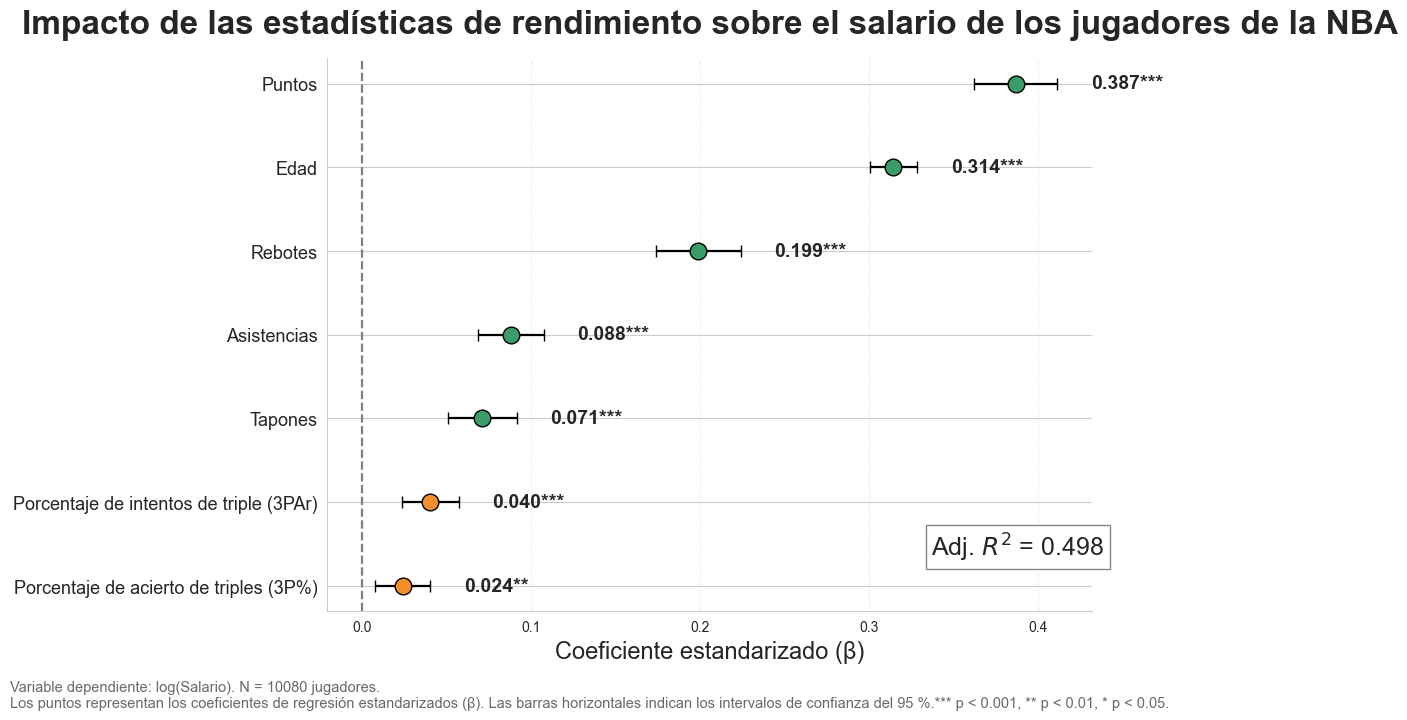

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler

# ======================================================
# Variables
# ======================================================

variables = [
    "PTS",
    "AST",
    "TRB",
    "BLK",
    "3PAr",
    "3P%",
    "Age"
]

# ======================================================
# Dataset
# ======================================================

df = (
    nba_master_final[
        variables + ["Salary"]
    ]
    .dropna()
    .copy()
)

# ======================================================
# Dependent variable
# ======================================================

df["LogSalary"] = np.log(df["Salary"])

# ======================================================
# Standardization
# ======================================================

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(df[variables]),
    columns=variables
)

y = StandardScaler().fit_transform(
    df[["LogSalary"]]
).ravel()

# ======================================================
# Multiple linear regression
# ======================================================

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

# ======================================================
# Results
# ======================================================

coef = model.params.drop("const")
ci = model.conf_int().drop("const")
pvalues = model.pvalues.drop("const")

results = pd.DataFrame({

    "Variable": coef.index,
    "Beta": coef.values,
    "Lower": ci[0].values,
    "Upper": ci[1].values,
    "p": pvalues.values

})

# ======================================================
# Labels
# ======================================================

labels = {

    "PTS": "Puntos",
    "TRB": "Rebotes",
    "AST": "Asistencias",
    "3PAr": "Porcentaje de intentos de triple (3PAr)",
    "3P%": "Porcentaje de acierto de triples (3P%)",
    "BLK": "Tapones",
    "Age": "Edad"

}

results["Label"] = results["Variable"].map(labels)

# ======================================================
# Manual order
# ======================================================

order = [

    "Puntos",
    "Edad",
    "Rebotes",
    "Asistencias",
    "Tapones",
    "Porcentaje de intentos de triple (3PAr)",
    "Porcentaje de acierto de triples (3P%)"
]

results["Label"] = pd.Categorical(
    results["Label"],
    categories=order,
    ordered=True
)

results = results.sort_values("Label")

# ======================================================
# Colors
# ======================================================

color_map = {

    "Puntos": "#3A9D68",
    "Rebotes": "#3A9D68",
    "Asistencias": "#3A9D68",
    "Edad": "#3A9D68",
    "Porcentaje de intentos de triple (3PAr)": "#F28E2B",

    "Porcentaje de acierto de triples (3P%)": "#F28E2B",

    "Tapones": "#3A9D68"

}

# ======================================================
# Figure
# ======================================================

sns.set_style("whitegrid")

fig, ax = plt.subplots(
    figsize=(11.8,7.2)
)

# ======================================================
# Zero line
# ======================================================

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.6
)

# ======================================================
# Forest plot
# ======================================================

for i, row in enumerate(results.itertuples()):

    color = color_map[row.Label]

    ax.errorbar(

        row.Beta,

        i,

        xerr=[
            [row.Beta-row.Lower],
            [row.Upper-row.Beta]
        ],

        fmt="o",

        color=color,

        markeredgecolor="black",

        markersize=12,

        ecolor="black",

        elinewidth=1.6,

        capsize=4

    )

    # Significance

    if row.p < 0.001:
        stars="***"

    elif row.p < 0.01:
        stars="**"

    elif row.p < 0.05:
        stars="*"

    else:
        stars=""

    ax.text(

        row.Upper + 0.02,

        i,

        f"{row.Beta:.3f}{stars}",

        fontsize=14,

        fontweight="bold",

        va="center"

    )

# ======================================================
# Axis
# ======================================================

ax.set_yticks(range(len(results)))

ax.set_yticklabels(
    results["Label"],
    fontsize=13
)

ax.invert_yaxis()

ax.set_xlabel(

    "Coeficiente estandarizado (β)",

    fontsize=17

)

ax.set_ylabel("")

# ======================================================
# Grid
# ======================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.30
)

sns.despine()

# ======================================================
# Adj R²
# ======================================================

ax.text(

    0.79,

    0.10,

    f"Adj. $R^2$ = {model.rsquared_adj:.3f}",

    transform=ax.transAxes,

    fontsize=18,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        alpha=.95

    )

)

# ======================================================
# Title
# ======================================================

plt.title(

    "Impacto de las estadísticas de rendimiento sobre el salario de los jugadores de la NBA",

    fontsize=24,

    weight="bold",

    pad=18

)

# ======================================================
# Footnote
# ======================================================

plt.figtext(

    0.01,

    0.01,

    f"Variable dependiente: log(Salario). N = {len(df)} jugadores.\n"
    "Los puntos representan los coeficientes de regresión estandarizados (β). "
    "Las barras horizontales indican los intervalos de confianza del 95 %."
    "*** p < 0.001, ** p < 0.01, * p < 0.05.",

    fontsize=10.5,

    color="dimgray"

)

plt.tight_layout(
    rect=[0,0.05,1,1]
)

plt.show()

### Random Forest

R²: 0.5399911281654336
RMSE: 0.8929221939874231


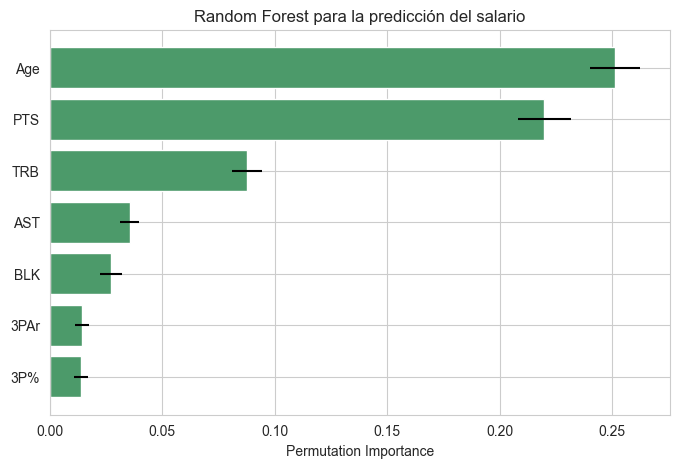

In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error

# Variables
X = salary_df[
    [
        "PTS",
        "AST",
        "TRB",
        "BLK",
        "3PAr",
        "3P%",
        "Age"
    ]
]

y = salary_df["LogSalary"]

# Train / Test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

# Modelo

rf = RandomForestRegressor(

    n_estimators=500,

    random_state=42,

    max_features="sqrt"

)

rf.fit(X_train, y_train)

# Predicción

pred = rf.predict(X_test)

print("R²:", r2_score(y_test,pred))

print("RMSE:", mean_squared_error(y_test,pred)**0.5)

perm = permutation_importance(

    rf,

    X_test,

    y_test,

    n_repeats=100,

    random_state=42,

    scoring="r2"

)

importance = pd.DataFrame({

    "Variable":X.columns,

    "Importance":perm.importances_mean,

    "Std":perm.importances_std

})

importance = importance.sort_values(
    "Importance"
)

plt.figure(figsize=(8,5))

plt.barh(

    importance["Variable"],

    importance["Importance"],

    xerr=importance["Std"],

    color="#4C9A6A"

)

plt.xlabel("Permutation Importance")

plt.title("Random Forest para la predicción del salario")

plt.show()

Los resultados obtenidos mediante Random Forest confirman las conclusiones de la regresión lineal. En ambos modelos, la anotación, la edad y la capacidad reboteadora constituyen los principales determinantes del salario, mientras que el volumen y la eficacia en el lanzamiento de tres puntos mantienen una contribución positiva, aunque de menor magnitud. La consistencia entre ambos enfoques refuerza la validez de los resultados obtenidos. 

## 4.12. Tiros de tres puntos y rendimiento del equipo

In [69]:
!pip install scipy


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Correlación con el Win%

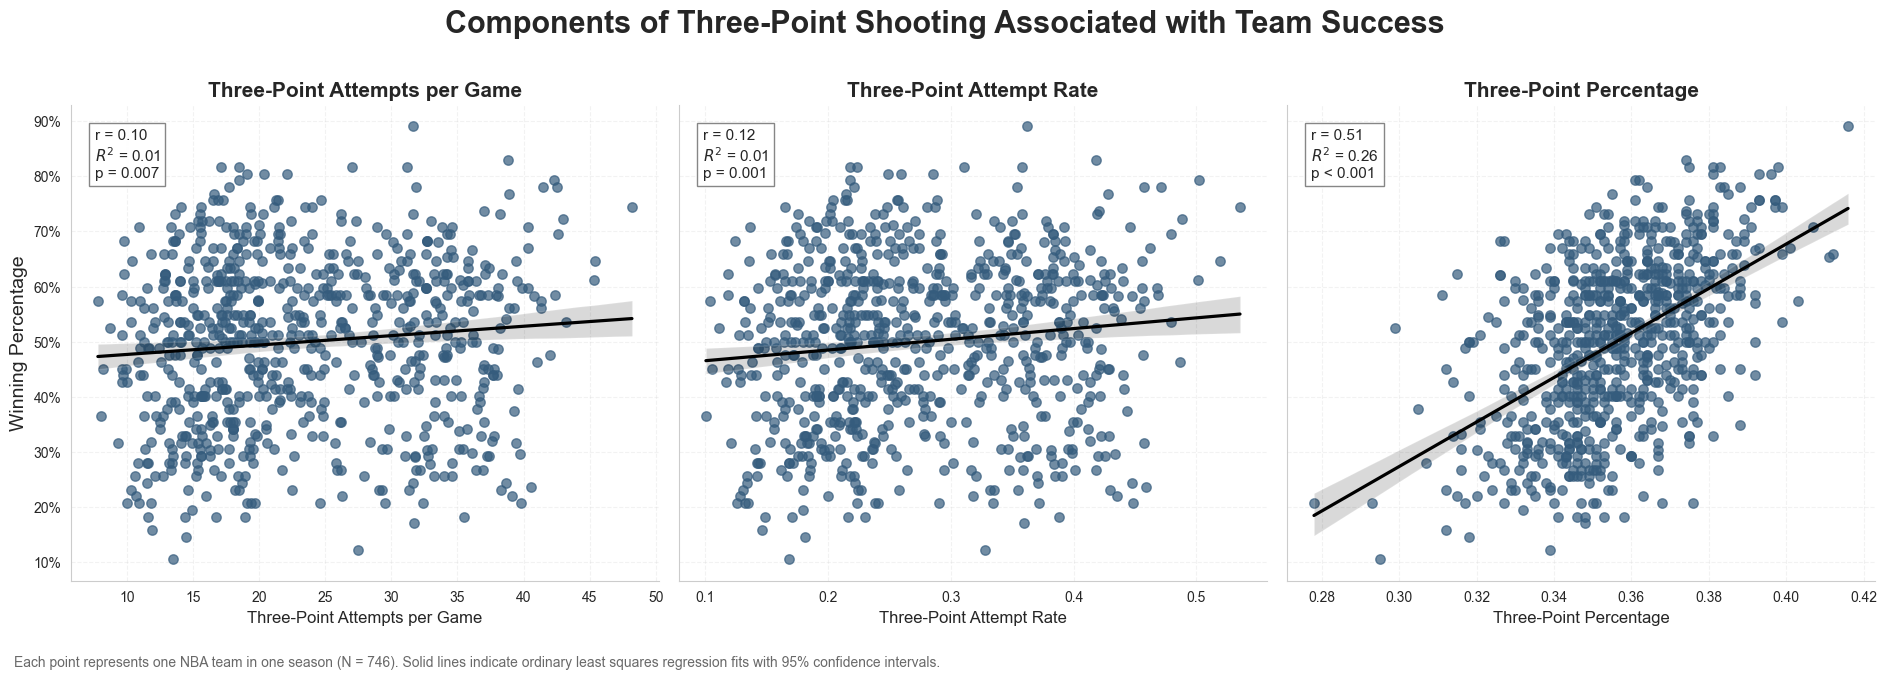

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

# ======================================================
# Team-level dataset
# ======================================================

team_df = (
    nba_master_final
    .drop_duplicates(subset=["SeasonYear", "Team"])
    [
        [
            "SeasonYear",
            "Team",
            "team_3pa_pg",
            "team_fga_pg",
            "team_3p_pct",
            "team_win_pct"
        ]
    ]
    .copy()
)

# ======================================================
# Team 3PAr
# ======================================================

team_df["team_3par"] = (
    team_df["team_3pa_pg"] /
    team_df["team_fga_pg"]
)

# ======================================================
# Variables a representar
# ======================================================

variables = [

    ("team_3pa_pg",
     "Three-Point Attempts per Game"),

    ("team_3par",
     "Three-Point Attempt Rate"),

    ("team_3p_pct",
     "Three-Point Percentage")

]

# ======================================================
# Figure
# ======================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6.5),
    sharey=True
)

main_color = "#355C7D"

# ======================================================
# Panels
# ======================================================

for ax, (var, label) in zip(axes, variables):

    sns.regplot(
        data=team_df,
        x=var,
        y="team_win_pct",
        ax=ax,

        scatter_kws=dict(
            s=46,
            alpha=0.70,
            color=main_color
        ),

        line_kws=dict(
            color="black",
            linewidth=2.3
        )
    )

    r, p = pearsonr(
        team_df[var],
        team_df["team_win_pct"]
    )

    ax.text(
        0.04,
        0.95,
        f"r = {r:.2f}\n"
        f"$R^2$ = {r**2:.2f}\n"
        f"{'p < 0.001' if p < 0.001 else f'p = {p:.3f}'}",

        transform=ax.transAxes,

        fontsize=11,

        va="top",

        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            alpha=0.95
        )
    )

    ax.set_title(
        label,
        fontsize=15,
        weight="bold"
    )

    ax.set_xlabel(label, fontsize=12)

# ======================================================
# Axis
# ======================================================

axes[0].set_ylabel(
    "Winning Percentage",
    fontsize=14
)

axes[1].set_ylabel("")
axes[2].set_ylabel("")

for ax in axes:

    ax.grid(
        linestyle="--",
        alpha=0.25
    )

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda y, _: f"{100*y:.0f}%"
        )
    )

    sns.despine(ax=ax)

# ======================================================
# Title
# ======================================================

fig.suptitle(
    "Components of Three-Point Shooting Associated with Team Success",
    fontsize=22,
    weight="bold",
    y=1.02
)

# ======================================================
# Footnote
# ======================================================

plt.figtext(
    0.01,
    0.01,
    f"Each point represents one NBA team in one season (N = {len(team_df)}). "
    "Solid lines indicate ordinary least squares regression fits with 95% confidence intervals.",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout(rect=[0,0.05,1,1])

plt.show()

### Correlación con el Net Rating

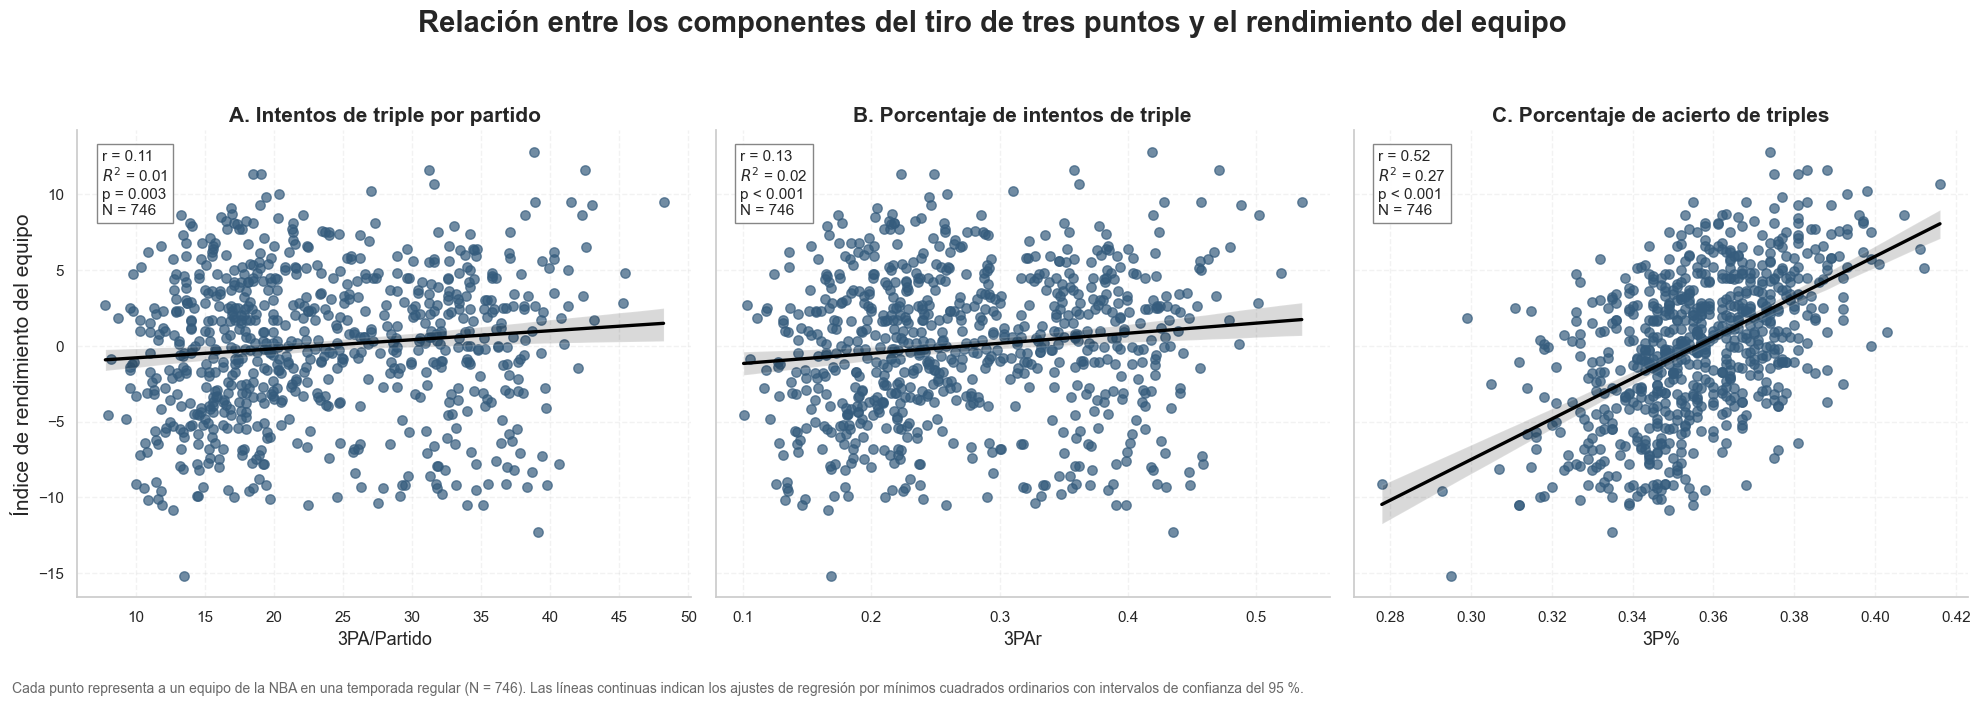

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

# ======================================================
# Team-level dataset
# ======================================================

team_df = (
    nba_master_final
    .drop_duplicates(subset=["SeasonYear", "Team"])
    [
        [
            "SeasonYear",
            "Team",
            "team_3pa_pg",
            "team_fga_pg",
            "team_3p_pct",
            "team_n_rtg"
        ]
    ]
    .dropna()
    .copy()
)

# ======================================================
# Calculate Team Three-Point Attempt Rate
# ======================================================

team_df["team_3par"] = (
    team_df["team_3pa_pg"] /
    team_df["team_fga_pg"]
)

# ======================================================
# Variables
# ======================================================

variables = [

    (
        "team_3pa_pg",
        "A. Intentos de triple por partido",
        "3PA/Partido"
    ),

    (
        "team_3par",
        "B. Porcentaje de intentos de triple",
        "3PAr"
    ),

    (
        "team_3p_pct",
        "C. Porcentaje de acierto de triples",
        "3P%"
    )

]

# ======================================================
# Figure
# ======================================================

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6.7),
    sharey=True
)

main_color = "#355C7D"

# ======================================================
# Panels
# ======================================================

for ax, (var, panel_title, xlabel) in zip(axes, variables):

    sns.regplot(
        data=team_df,
        x=var,
        y="team_n_rtg",
        ci=95,
        ax=ax,

        scatter_kws=dict(
            s=46,
            alpha=0.70,
            color=main_color
        ),

        line_kws=dict(
            color="black",
            linewidth=2.4
        )
    )

    r, p = pearsonr(
        team_df[var],
        team_df["team_n_rtg"]
    )

    ax.text(
        0.04,
        0.96,
        f"r = {r:.2f}\n"
        f"$R^2$ = {r**2:.2f}\n"
        f"{'p < 0.001' if p < 0.001 else f'p = {p:.3f}'}\n"
        f"N = {len(team_df)}",

        transform=ax.transAxes,

        fontsize=11,

        va="top",

        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            alpha=0.95
        )
    )

    ax.set_title(
        panel_title,
        fontsize=15,
        weight="bold"
    )

    ax.set_xlabel(
        xlabel,
        fontsize=13
    )

# ======================================================
# Axis formatting
# ======================================================

axes[0].set_ylabel(
    "Índice de rendimiento del equipo",
    fontsize=15
)

axes[1].set_ylabel("")
axes[2].set_ylabel("")

for ax in axes:

    ax.grid(
        linestyle="--",
        alpha=0.25
    )

    ax.tick_params(
        labelsize=11
    )

    sns.despine(ax=ax)

# ======================================================
# Title
# ======================================================

fig.suptitle(
    "Relación entre los componentes del tiro de tres puntos y el rendimiento del equipo",
    fontsize=21,
    weight="bold",
    y=1.03
)

# ======================================================
# Footnote
# ======================================================

plt.figtext(
    0.01,
    0.01,
    "Cada punto representa a un equipo de la NBA en una temporada regular (N = 746). " 
    "Las líneas continuas indican los ajustes de regresión por mínimos cuadrados ordinarios con intervalos de confianza del 95 %.",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout(
    rect=[0, 0.05, 1, 0.98]
)

plt.show()

La Figura 4.12 evidencia que el rendimiento de los equipos se relaciona principalmente con la eficacia en el lanzamiento de tres puntos y no con el volumen de triples intentados. Mientras que el número de triples por partido y el 3PAr presentan correlaciones muy débiles con el Net Rating (r = 0.11 y r = 0.13, respectivamente), el porcentaje de acierto en triples muestra una asociación positiva moderada (r = 0.52; p < 0.001), lo que sugiere que la calidad del tiro exterior constituye un factor más relevante para el rendimiento colectivo que la cantidad de lanzamientos realizados.

### Comparación entre gráficas 4.11 y 4.12:

#### Los resultados muestran que el mercado salarial de la NBA recompensa tanto el volumen como la eficacia del lanzamiento de tres puntos, aunque el volumen de tiro exterior (3PAr) presenta un mayor efecto sobre el salario. Sin embargo, el rendimiento colectivo de los equipos depende principalmente del porcentaje de acierto en triples (3P%), mientras que el volumen de lanzamientos muestra una capacidad explicativa muy limitada.

## 4.13. Regresión lineal múltiple para predecir el indíce de rendimiento del equipo

#### ¿Qué variables explican el rendimiento del equipo cuando se analizan simultáneamente?

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

variables = [

    "team_3p_pct",
    "team_3pa_share",
    "team_tov_percent",
    "team_orb_percent",
    "team_pace"

]

X = (

    nba_master_final
    .drop_duplicates(subset=["SeasonYear","Team"])[variables]
    .dropna()
)

# Añadir constante
X = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [

    variance_inflation_factor(X.values, i)

    for i in range(X.shape[1])

]

print(vif)

           Variable          VIF
0             const  2296.146093
1       team_3p_pct     1.148333
2    team_3pa_share     1.021172
3  team_tov_percent     1.278199
4  team_orb_percent     1.646944
5         team_pace     1.576106


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     85.22
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           1.00e-70
Time:                        00:16:48   Log-Likelihood:                -888.90
No. Observations:                 746   AIC:                             1790.
Df Residuals:                     740   BIC:                             1817.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             7.373e-18      0.029  

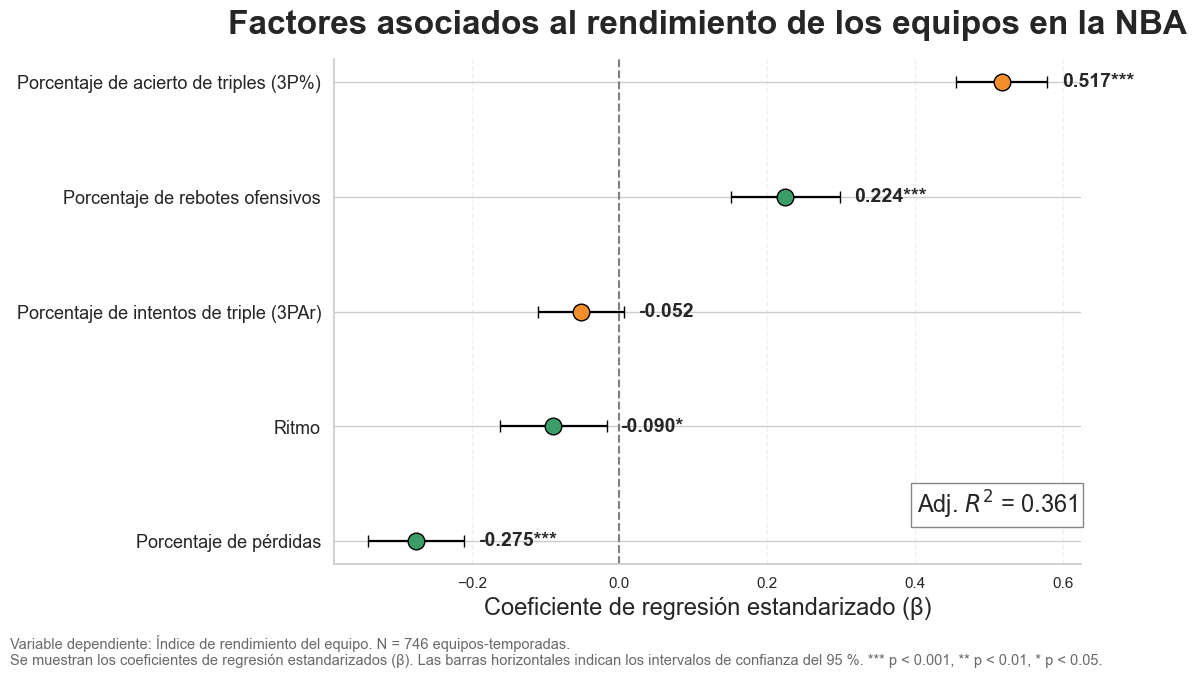

In [73]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler

# ======================================================
# Variables del modelo
# ======================================================

variables = [

    "team_3p_pct",
    "team_3pa_share",
    "team_tov_percent",
    "team_orb_percent",
    "team_pace"

]

# ======================================================
# Dataset de equipos
# ======================================================

team_df = (

    nba_master_final

    .drop_duplicates(
        subset=["SeasonYear", "Team"]
    )

    [

        variables +

        ["team_n_rtg"]

    ]

    .dropna()

    .copy()

)

# ======================================================
# Estandarización
# ======================================================

scaler = StandardScaler()

X = pd.DataFrame(

    scaler.fit_transform(team_df[variables]),

    columns=variables

)

y = StandardScaler().fit_transform(

    team_df[["team_n_rtg"]]

).ravel()

# ======================================================
# Modelo OLS
# ======================================================

X = sm.add_constant(X)

model = sm.OLS(

    y,

    X

).fit()

print(model.summary())

# ======================================================
# Resultados
# ======================================================

coef = model.params.drop("const")

ci = model.conf_int().drop("const")

pvalues = model.pvalues.drop("const")

results = pd.DataFrame({

    "Variable":coef.index,

    "Beta":coef.values,

    "Lower":ci[0].values,

    "Upper":ci[1].values,

    "p":pvalues.values

})

# ======================================================
# Etiquetas
# ======================================================

labels = {

    "team_3p_pct":"Porcentaje de acierto de triples (3P%)",

    "team_3pa_share":"Porcentaje de intentos de triple (3PAr)",

    "team_tov_percent":"Porcentaje de pérdidas",

    "team_orb_percent":"Porcentaje de rebotes ofensivos",

    "team_pace":"Ritmo"

}

results["Label"] = results["Variable"].map(labels)

# ======================================================
# Orden
# ======================================================

order = [

    "Porcentaje de acierto de triples (3P%)",

    "Porcentaje de rebotes ofensivos",

    "Porcentaje de intentos de triple (3PAr)",

    "Ritmo",

    "Porcentaje de pérdidas"
]

results["Label"] = pd.Categorical(

    results["Label"],

    categories=order,

    ordered=True

)

results = results.sort_values("Label")

# ======================================================
# Colores
# ======================================================

color_map = {

    "Porcentaje de acierto de triples (3P%)":"#F28E2B",

    "Porcentaje de intentos de triple (3PAr)":"#F28E2B",

    "Porcentaje de pérdidas":"#3A9D68",

    "Porcentaje de rebotes ofensivos":"#3A9D68",

    "Ritmo":"#3A9D68"

}

# ======================================================
# Figura
# ======================================================

sns.set_style("whitegrid")

fig, ax = plt.subplots(

    figsize=(11.5, 6.8)

)

# ======================================================
# Línea de referencia
# ======================================================

ax.axvline(

    0,

    color="gray",

    linestyle="--",

    linewidth=1.5

)

# ======================================================
# Forest plot
# ======================================================

for i, row in enumerate(results.itertuples()):

    color = color_map[row.Label]

    ax.errorbar(

        row.Beta,

        i,

        xerr=[

            [row.Beta-row.Lower],

            [row.Upper-row.Beta]

        ],

        fmt="o",

        markersize=12,

        color=color,

        markeredgecolor="black",

        ecolor="black",

        elinewidth=1.6,

        capsize=4

    )

    if row.p < 0.001:

        stars="***"

    elif row.p < 0.01:

        stars="**"

    elif row.p < 0.05:

        stars="*"

    else:

        stars=""

    ax.text(

        row.Upper + 0.02,

        i,

        f"{row.Beta:.3f}{stars}",

        fontsize=14,

        fontweight="bold",

        va="center"

    )

# ======================================================
# Ejes
# ======================================================

ax.set_yticks(

    range(len(results))

)

ax.set_yticklabels(

    results["Label"],

    fontsize=13

)

ax.invert_yaxis()

ax.set_xlabel(

    "Coeficiente de regresión estandarizado (β)",

    fontsize=17

)

ax.set_ylabel("")

# ======================================================
# Grid
# ======================================================

ax.grid(

    axis="x",

    linestyle="--",

    alpha=.30

)

sns.despine()

# ======================================================
# Adj R²
# ======================================================

ax.text(

    0.78,

    0.10,

    f"Adj. $R^2$ = {model.rsquared_adj:.3f}",

    transform=ax.transAxes,

    fontsize=17,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        alpha=.95

    )

)

# ======================================================
# Título
# ======================================================

plt.title(

    "Factores asociados al rendimiento de los equipos en la NBA",

    fontsize=24,

    weight="bold",

    pad=18

)

# ======================================================
# Pie de figura
# ======================================================

plt.figtext(

    0.01,

    0.01,

    f"Variable dependiente: Índice de rendimiento del equipo. N = {len(team_df)} equipos-temporadas.\n"
    "Se muestran los coeficientes de regresión estandarizados (β). "
    "Las barras horizontales indican los intervalos de confianza del 95 %. "
    "*** p < 0.001, ** p < 0.01, * p < 0.05.",

    fontsize=10.5,

    color="dimgray"

)

plt.tight_layout(

    rect=[0,0.05,1,1]

)

plt.show()

## OPCIÓN B: MEJORADA

In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

variables = [

    "team_3p_pct",
    "team_3pa_share",
    "team_tov_percent",
    "team_orb_percent",
    "team_pace",
    "team_ts_percent",
    "team_drb_percent"
]

X = (

    nba_master_final
    .drop_duplicates(subset=["SeasonYear","Team"])[variables]
    .dropna()
)

# Añadir constante
X = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [

    variance_inflation_factor(X.values, i)

    for i in range(X.shape[1])

]

print(vif)

           Variable          VIF
0             const  3500.629233
1       team_3p_pct     1.869136
2    team_3pa_share     1.037611
3  team_tov_percent     1.356152
4  team_orb_percent     1.807055
5         team_pace     2.357404
6   team_ts_percent     3.150966
7  team_drb_percent     1.732297


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     130.8
Date:                Wed, 01 Jul 2026   Prob (F-statistic):          9.54e-125
Time:                        00:16:48   Log-Likelihood:                -757.62
No. Observations:                 746   AIC:                             1531.
Df Residuals:                     738   BIC:                             1568.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             7.373e-18      0.025  

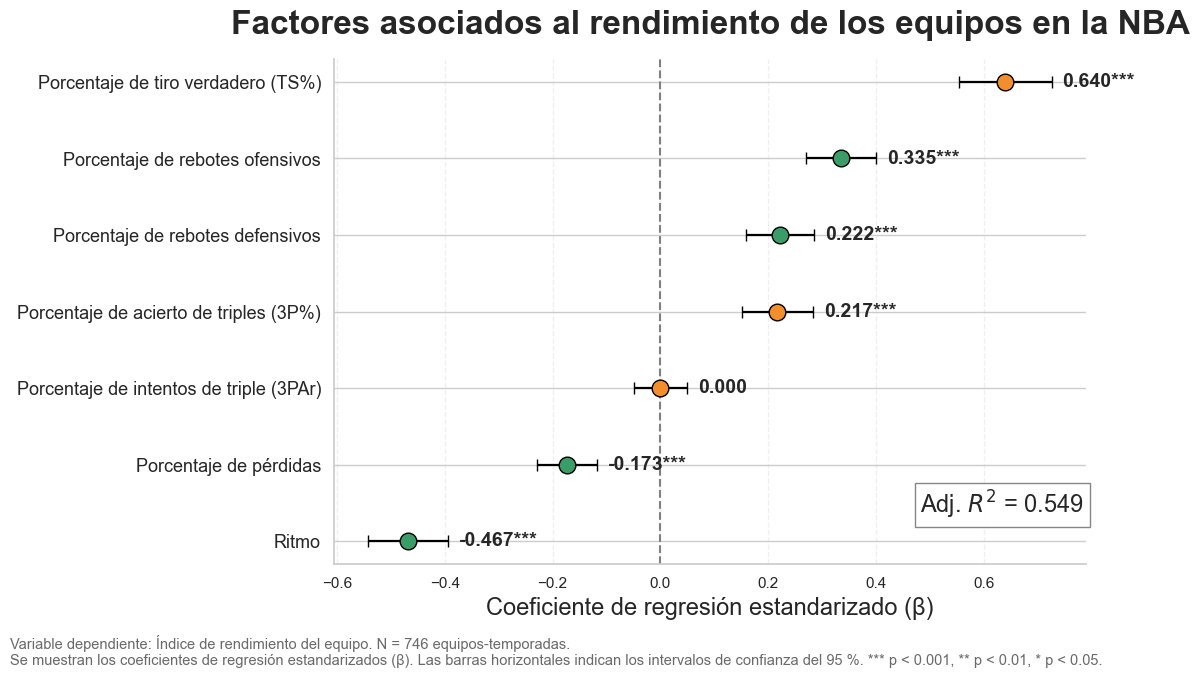

In [75]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler

# ======================================================
# Variables del modelo
# ======================================================

variables = [

    "team_3p_pct",
    "team_3pa_share",
    "team_tov_percent",
    "team_orb_percent",
    "team_pace",
    "team_ts_percent",
    "team_drb_percent"
]

# ======================================================
# Dataset de equipos
# ======================================================

team_df = (

    nba_master_final

    .drop_duplicates(
        subset=["SeasonYear", "Team"]
    )

    [

        variables +

        ["team_n_rtg"]

    ]

    .dropna()

    .copy()

)

# ======================================================
# Estandarización
# ======================================================

scaler = StandardScaler()

X = pd.DataFrame(

    scaler.fit_transform(team_df[variables]),

    columns=variables

)

y = StandardScaler().fit_transform(

    team_df[["team_n_rtg"]]

).ravel()

# ======================================================
# Modelo OLS
# ======================================================

X = sm.add_constant(X)

model = sm.OLS(

    y,

    X

).fit()

print(model.summary())

# ======================================================
# Resultados
# ======================================================

coef = model.params.drop("const")

ci = model.conf_int().drop("const")

pvalues = model.pvalues.drop("const")

results = pd.DataFrame({

    "Variable":coef.index,

    "Beta":coef.values,

    "Lower":ci[0].values,

    "Upper":ci[1].values,

    "p":pvalues.values

})

# ======================================================
# Etiquetas
# ======================================================

labels = {

    "team_3p_pct":"Porcentaje de acierto de triples (3P%)",

    "team_3pa_share":"Porcentaje de intentos de triple (3PAr)",

    "team_tov_percent":"Porcentaje de pérdidas",

    "team_orb_percent":"Porcentaje de rebotes ofensivos",

    "team_pace":"Ritmo",

    "team_ts_percent": "Porcentaje de tiro verdadero (TS%)",

    "team_drb_percent": "Porcentaje de rebotes defensivos"
}

results["Label"] = results["Variable"].map(labels)

# ======================================================
# Orden
# ======================================================

order = [

    "Porcentaje de tiro verdadero (TS%)",

    "Porcentaje de rebotes ofensivos",

    "Porcentaje de rebotes defensivos",

    "Porcentaje de acierto de triples (3P%)",

    "Porcentaje de intentos de triple (3PAr)",

    "Porcentaje de pérdidas",

    "Ritmo"      
]

results["Label"] = pd.Categorical(

    results["Label"],

    categories=order,

    ordered=True

)

results = results.sort_values("Label")

# ======================================================
# Colores
# ======================================================

color_map = {

    "Porcentaje de acierto de triples (3P%)":"#F28E2B",

    "Porcentaje de intentos de triple (3PAr)":"#F28E2B",

    "Porcentaje de pérdidas":"#3A9D68",

    "Porcentaje de rebotes ofensivos":"#3A9D68",

    "Ritmo":"#3A9D68",

    "Porcentaje de tiro verdadero (TS%)": "#F28E2B",

    "Porcentaje de rebotes defensivos": "#3A9D68"
}

# ======================================================
# Figura
# ======================================================

sns.set_style("whitegrid")

fig, ax = plt.subplots(

    figsize=(11.5, 6.8)

)

# ======================================================
# Línea de referencia
# ======================================================

ax.axvline(

    0,

    color="gray",

    linestyle="--",

    linewidth=1.5

)

# ======================================================
# Forest plot
# ======================================================

for i, row in enumerate(results.itertuples()):

    color = color_map[row.Label]

    ax.errorbar(

        row.Beta,

        i,

        xerr=[

            [row.Beta-row.Lower],

            [row.Upper-row.Beta]

        ],

        fmt="o",

        markersize=12,

        color=color,

        markeredgecolor="black",

        ecolor="black",

        elinewidth=1.6,

        capsize=4

    )

    if row.p < 0.001:

        stars="***"

    elif row.p < 0.01:

        stars="**"

    elif row.p < 0.05:

        stars="*"

    else:

        stars=""

    ax.text(

        row.Upper + 0.02,

        i,

        f"{row.Beta:.3f}{stars}",

        fontsize=14,

        fontweight="bold",

        va="center"

    )

# ======================================================
# Ejes
# ======================================================

ax.set_yticks(

    range(len(results))

)

ax.set_yticklabels(

    results["Label"],

    fontsize=13

)

ax.invert_yaxis()

ax.set_xlabel(

    "Coeficiente de regresión estandarizado (β)",

    fontsize=17

)

ax.set_ylabel("")

# ======================================================
# Grid
# ======================================================

ax.grid(

    axis="x",

    linestyle="--",

    alpha=.30

)

sns.despine()

# ======================================================
# Adj R²
# ======================================================

ax.text(

    0.78,

    0.10,

    f"Adj. $R^2$ = {model.rsquared_adj:.3f}",

    transform=ax.transAxes,

    fontsize=17,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        alpha=.95

    )

)

# ======================================================
# Título
# ======================================================

plt.title(

    "Factores asociados al rendimiento de los equipos en la NBA",

    fontsize=24,

    weight="bold",

    pad=18

)

# ======================================================
# Pie de figura
# ======================================================

plt.figtext(

    0.01,

    0.01,

    f"Variable dependiente: Índice de rendimiento del equipo. N = {len(team_df)} equipos-temporadas.\n"
    "Se muestran los coeficientes de regresión estandarizados (β). "
    "Las barras horizontales indican los intervalos de confianza del 95 %. "
    "*** p < 0.001, ** p < 0.01, * p < 0.05.",

    fontsize=10.5,

    color="dimgray"

)

plt.tight_layout(

    rect=[0,0.05,1,1]

)

plt.show()

## 4.14. Random Forest Variable Importance for Predicting NBA Playoff Qualification

R²: 0.5408159450626495
RMSE: 3.4582090625680526


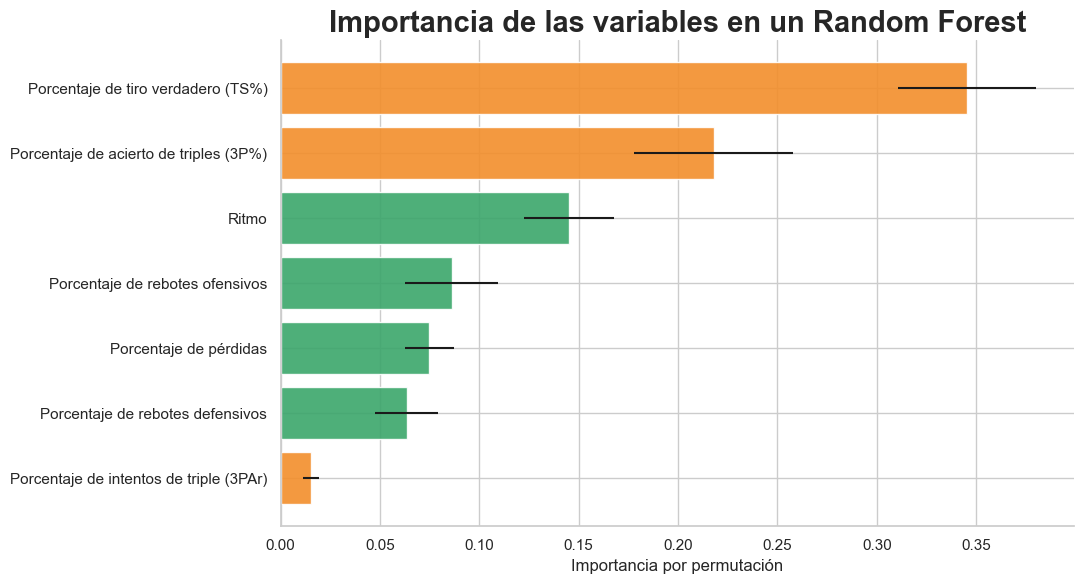

In [76]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# Variables
# ======================================================

variables = [

    "team_3p_pct",
    "team_3pa_share",
    "team_tov_percent",
    "team_orb_percent",
    "team_pace",
    "team_ts_percent",
    "team_drb_percent"

]

# ======================================================
# Dataset de equipos
# ======================================================

team_df = (
    nba_master_final
    .drop_duplicates(subset=["SeasonYear","Team"])
)

team_df = team_df.dropna(
    subset=variables + ["team_n_rtg"]
)

X = team_df[variables]

y = team_df["team_n_rtg"]

# ======================================================
# Train/Test
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.25,
    random_state=42

)

# ======================================================
# Random Forest
# ======================================================

rf = RandomForestRegressor(

    n_estimators=500,
    random_state=42,
    max_features="sqrt"

)

rf.fit(X_train, y_train)

# ======================================================
# Predicciones
# ======================================================

pred = rf.predict(X_test)

print("R²:", r2_score(y_test, pred))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred))
)

# ======================================================
# Permutation importance
# ======================================================

perm = permutation_importance(

    rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42

)

importance = (
    pd.DataFrame({

        "Variable": variables,
        "Importance": perm.importances_mean,
        "Std": perm.importances_std

    })
    .sort_values("Importance")
)

# ======================================================
# Colores
# ======================================================

colors = []

for var in importance["Variable"]:

    if var in [
        "team_ts_percent",
        "team_3p_pct",
        "team_3pa_share"
    ]:

        colors.append("#F28E2B")   # naranja

    else:

        colors.append("#3BA66B")   # verde

# ======================================================
# Etiquetas
# ======================================================

labels = {

    "team_ts_percent":
        "Porcentaje de tiro verdadero (TS%)",

    "team_3p_pct":
        "Porcentaje de acierto de triples (3P%)",

    "team_3pa_share":
        "Porcentaje de intentos de triple (3PAr)",

    "team_tov_percent":
        "Porcentaje de pérdidas",

    "team_orb_percent":
        "Porcentaje de rebotes ofensivos",

    "team_drb_percent":
        "Porcentaje de rebotes defensivos",

    "team_pace":
        "Ritmo"

}

# ======================================================
# Figura
# ======================================================

plt.figure(figsize=(11,6))

bars = plt.barh(

    [labels[v] for v in importance["Variable"]],

    importance["Importance"],

    xerr=importance["Std"],

    color=colors,

    alpha=.9

)

plt.xlabel(
    "Importancia por permutación"
)

plt.title(

    "Importancia de las variables en un Random Forest",

    fontsize=21,

    weight="bold"

)

sns.despine()

plt.tight_layout()

plt.show()